# AIOMFAC Activity-Coefficient Surrogate: Full Reproduction Notebook

This notebook reproduces every table and figure in *"A Fast Neural-Network Surrogate for AIOMFAC Activity Coefficients: Feature Design, Functional-Group Coverage Limits, and Downstream Applications to Viscosity Prediction and Global Sensitivity Analysis"* (`aiomfac_surrogate_paper_draft.docx`), by concatenating the four research notebooks the paper synthesizes (Directions 1, 3, 4, 5) into one linear, self-contained pipeline.

**Structure** (each part's own notebook is still separately available, unmodified, in the project's `colab_deliver/` folder for standalone reruns):

| Part | Source notebook | Paper section(s) | Produces |
|---|---|---|---|
| I | `aiomfac_surrogate_direction1.ipynb` | Sec. 2.1-2.3, 3.1-3.3 | Table 1, Figure 1, halogen-coverage finding |
| II | `aiomfac_direction3_gnn.ipynb` | Sec. 2.4, 3.4-3.6 | Table 2, Figure 2 |
| III | `aiomfac_direction4_viscosity.ipynb` | Sec. 2.5, 3.7 | Table 3, Figure 3 |
| IV | `aiomfac_direction5_gsa.ipynb` | Sec. 2.6, 3.8 | Figure 4 (Sobol indices) |
| V | *(new; this notebook only)* | Sec. 2.7, 3.9 | Table 4, Figure 5 (speed benchmark) |

Run all cells top to bottom in Google Colab (GPU not required; Part II's GNN training is faster with one). Each part is independent and can also be run on its own after Part I's setup cell.


---
## Part I -- Surrogate architecture, feature ablation, dataset-size effect, halogen coverage
*(paper Sec. 2.1-2.3 and 3.1-3.3; produces Table 1 / Figure 1)*

Trains the hand-crafted-feature MLP surrogate against AIOMFAC-computed labels for the BIMOG compound set, runs the feature-representation ablation (raw subgroup counts vs. hand-crafted main-group fractions vs. learned embedding), grows the training pool from 243 to 468 molecules, and checks AIOMFAC's SMILES decomposer for halogen-specific subgroups.

# AIOMFAC Surrogate Model (Direction 1) -- Full Pipeline, Run-It-Yourself

This notebook reproduces, end to end, Direction 1 of the `aiomfac_py` ML/DL research roadmap: training a
fast neural-network surrogate that reproduces `aiomfac_py.ActivityModel` (the AIOMFAC group-contribution
activity-coefficient model) across composition/temperature space, without running the iterative
group-contribution solver each time.

It walks through the whole experiment history in order, including a couple of dead ends and a bug fix,
because the "why" matters as much as the final numbers:

1. Install `aiomfac_py` (+ the optional `s2as` SMILES decomposer) and RDKit/PyTorch.
2. Build the first surrogate on 243 CHO-only organics; evaluate interpolation vs. generalization.
3. Feature ablation: raw subgroup counts vs. hand-engineered "rich" features vs. a learned embedding.
4. Expand to the full 368-compound BIMOG set (adds N/halogen-containing organics).
5. **The halogen-coverage finding**: AIOMFAC (as ported here) has no halogen subgroups at all -- verified
   directly, with consequences for every later result involving halogens.
6. Grow the nitrogen-containing pool, first with homologous series, then with structurally diverse
   substitution patterns -- and a methodology bug (train/test split drifting across pool sizes) caught and
   fixed along the way.
7. Final, fair three-pool comparison and an honest discussion of what did and didn't work.

Runtime: CPU-only Colab is fine (a few minutes total); no GPU needed.

## Prerequisites

Nothing to upload -- this notebook generates all its own data by calling AIOMFAC directly. It only needs
the BIMOG compound table (`bimog_unified.json`, 368 real organic compounds with names, SMILES, and
elemental composition) that an earlier experiment in this project already produced; upload it below.


In [1]:
# Upload bimog_unified.json (Colab only). Skip this cell if you already placed it in the file browser.
try:
    from google.colab import files
    import os
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")


Not running in Colab -- make sure bimog_unified.json is in the current directory.


## 1) Install `aiomfac_py` (with the `s2as` SMILES decomposer) and dependencies

Same install pattern as `aiomfac-python/notebooks/bootstrap_colab.ipynb`, but with `INSTALL_SMILES = True`
this time, since this whole notebook runs on SMILES -> AIOMFAC-subgroup decomposition.


In [2]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/SeoulTechPSE/aiomfac-python.git"
ROOT = Path.cwd()  # was hard-coded to "/content" (Colab-only path); use cwd so this also works locally
REPO_DIR = ROOT / "aiomfac-python"

def run(cmd):
    subprocess.run(cmd, check=True)

if not REPO_DIR.exists():
    print("Cloning aiomfac-python...")
    run(["git", "clone", REPO_URL, str(REPO_DIR)])
else:
    print("Repository already exists -- pulling latest...")
    try:
        run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"])
    except Exception as e:
        print("(pull skipped:", e, ")")

try:
    import aiomfac_py
    from aiomfac_py.s2as import smiles_to_components  # noqa: F401
    print(f"aiomfac_py {aiomfac_py.__version__} already importable (incl. s2as) "
          "-- skipping setup_aiomfac.py install step")
except ImportError:
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate --smiles")


Cloning aiomfac-python...


Cloning into '/tmp/claude-0/-home-claude/eecda288-448a-508f-8b60-1c1c2ce4350c/scratchpad/nb_work/aiomfac-python'...


aiomfac_py 0.0.24 already importable (incl. s2as) -- skipping setup_aiomfac.py install step


*A quick housekeeping cell: AIOMFAC's SMILES decomposer (`aiomfac_py.s2as._mapping`) unconditionally `print()`s a two-line warning every time a molecule's atoms are not fully matched to AIOMFAC subgroups -- expected and harmless for many of the combinatorial synthetic molecules generated in Part II, but very noisy over a few hundred of them. The cell below silences only those prints (not exceptions or returned values, which the pipeline still uses normally to flag/exclude affected molecules); comment it out if you want to see the raw warnings for debugging.*

In [3]:
# Silence aiomfac_py.s2as's noisy per-molecule subgroup-mismatch print() statements.
# (They are informational only -- the function's returned unmatched-atom count is what
# the pipeline actually uses to flag/exclude affected molecules, and is unaffected by this.)
import aiomfac_py.s2as._mapping as _aiomfac_mapping
_aiomfac_mapping.print = lambda *args, **kwargs: None
print("aiomfac_py.s2as subgroup-mismatch warnings silenced for this session")


aiomfac_py.s2as subgroup-mismatch warnings silenced for this session


In [4]:
# RDKit (for O:C / N:C / molar-mass features) and PyTorch (for the surrogate MLP)
try:
    from rdkit import Chem  # noqa: F401
    print("rdkit already installed, skipping pip install")
except ImportError:
    get_ipython().system("pip install -q rdkit 2>&1 | tail -3")
import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())

import aiomfac_py as aiomfac
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py import ActivityModel, Component
from aiomfac_py.params import load_subgroup_params
print(f"aiomfac_py {aiomfac.__version__} imported OK, s2as available")


rdkit already installed, skipping pip install


torch 2.14.1+cu130 | CUDA available: False
aiomfac_py 0.0.24 imported OK, s2as available


## 2) First surrogate: 243 CHO-only organics, raw subgroup-count features

Pick the 243 CHO-only (no nitrogen, no halogen) organics out of `bimog_unified.json` (already decomposed
to AIOMFAC subgroups in an earlier step of this project; here they get re-decomposed from SMILES via
`s2as` for a fully self-contained notebook). For each one, sample 20 water-mass-fraction points x 4
temperatures (273-313 K) and label every point with AIOMFAC's own `ln(gamma_water)` and
`ln(gamma_organic)`. Train a 3-hidden-layer MLP on (molecule features + composition + temperature) ->
(ln gamma water, ln gamma organic), with **two** held-out test sets: interpolation (new composition/T on
molecules seen during training) and generalization (molecules never seen at all).


In [5]:
import json, time
import numpy as np
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)
sg = load_subgroup_params()

with open("bimog_unified.json") as f:
    bimog = json.load(f)
print(f"BIMOG set: {len(bimog)} compounds "
      f"({sum(1 for d in bimog if d['#N'] == 0 and d['#Hal'] == 0)} CHO-only, "
      f"{sum(1 for d in bimog if d['#N'] != 0 or d['#Hal'] != 0)} N/halogen-containing)")


def decompose_pool(candidates):
    '''SMILES -> AIOMFAC Component, with a sanity-check AIOMFAC evaluate() call and RDKit O:C/N:C/MW.'''
    from rdkit import Chem
    kept, removed = [], []
    for d in candidates:
        smi = d["smiles"]
        r = smiles_to_components([smi], water_as_component1=True)
        if r.removed:
            removed.append((d["name"], smi, r.removed[0][2]))
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                raise ValueError("non-positive gamma at sanity point")
        except Exception as exc:
            removed.append((d["name"], smi, f"ActivityModel failed: {exc}"))
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            removed.append((d["name"], smi, "RDKit could not parse"))
            continue
        mol_h = Chem.AddHs(mol)
        n_c = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "C")
        n_o = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "O")
        n_n = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "N")
        mw = sum(a.GetMass() for a in mol_h.GetAtoms())
        kept.append({"name": d["name"], "smiles": smi, "category": d.get("category", "cho"),
                     "subgroups": organic.subgroups, "molar_mass_g_mol": mw,
                     "o_to_c": n_o / max(n_c, 1), "n_to_c": n_n / max(n_c, 1)})
    return kept, removed


bimog_cho_cands = [{"smiles": d["smiles"], "name": d["name"], "category": "cho"}
                   for d in bimog if d["#N"] == 0 and d["#Hal"] == 0]
pool_cho, removed_cho = decompose_pool(bimog_cho_cands)
print(f"kept {len(pool_cho)} / {len(bimog_cho_cands)} CHO-only organics ({len(removed_cho)} removed)")


BIMOG set: 368 compounds (243 CHO-only, 125 N/halogen-containing)


kept 243 / 243 CHO-only organics (0 removed)


In [6]:
def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    '''Sample water-mass-fraction x temperature points for each organic and label with AIOMFAC.'''
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        water = Component(1, "Water", ((16, 1),))
        organic = Component(2, o["name"], tuple((s, q) for s, q in o["subgroups"]))
        try:
            m = ActivityModel([water, organic])
        except Exception:
            continue
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        wtf_water = rng.uniform(edges[:-1], edges[1:])
        temps = rng.uniform(273.15, 313.15, n_temp)
        for wtf_w in wtf_water:
            for T in temps:
                try:
                    res = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass")
                    lw, lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
                    if np.isfinite(lw) and np.isfinite(lo):
                        rows.append({"organic_idx": oi, "wtf_water": float(wtf_w), "T_K": float(T),
                                    "ln_gamma_water": lw, "ln_gamma_organic": lo})
                except Exception:
                    continue
    return rows


t0 = time.time()
rows_cho = build_dataset(pool_cho)
print(f"generated {len(rows_cho)} labeled points from {len(pool_cho)} organics in {time.time()-t0:.1f}s")


generated 19440 labeled points from 243 organics in 3.1s


In [7]:
def raw_count_features(kept):
    '''Baseline feature set: raw per-subgroup counts (sparse, 'vocabulary'-style).'''
    vocab = sorted({int(s) for o in kept for s, q in o["subgroups"]})
    vidx = {s: i for i, s in enumerate(vocab)}
    feat = np.zeros((len(kept), len(vocab)), dtype=np.float32)
    for oi, o in enumerate(kept):
        for s, q in o["subgroups"]:
            feat[oi, vidx[int(s)]] = q
    return feat


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


def to_t(a):
    return torch.tensor(a, dtype=torch.float32)


def train_and_eval(kept, rows, feat, test_mols, label=""):
    '''One full train+eval cycle: molecule-level held-out generalization split + point-level
    interpolation split on the remaining (seen) molecules. test_mols = set of organic indices to hold out
    entirely (never seen during training) -- the *generalization* test.'''
    t0 = time.time()
    organic_idx = np.array([r["organic_idx"] for r in rows])
    X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in rows], dtype=np.float32)
    y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows], dtype=np.float32)
    X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)

    train_mask = ~np.isin(organic_idx, list(test_mols))
    gen_mask = np.isin(organic_idx, list(test_mols))
    train_idx_all = np.where(train_mask)[0]
    rng = np.random.RandomState(0)
    perm = rng.permutation(len(train_idx_all))
    n_interp = int(0.2 * len(train_idx_all))
    interp_idx = train_idx_all[perm[:n_interp]]
    fit_idx = train_idx_all[perm[n_interp:]]
    gen_idx = np.where(gen_mask)[0]
    n_val = int(0.1 * len(fit_idx))
    val_sel, fit_sel = np.arange(n_val), np.arange(n_val, len(fit_idx))

    x_mean, x_std = X[fit_idx].mean(0), X[fit_idx].std(0) + 1e-6
    y_mean, y_std = y[fit_idx].mean(0), y[fit_idx].std(0) + 1e-6
    Xn, Yn = (X - x_mean) / x_std, (y - y_mean) / y_std
    X_fit_t, Y_fit_t = to_t(Xn[fit_idx]), to_t(Yn[fit_idx])

    model = MLPHead(X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(500):
        model.train()
        perm_e = np.random.permutation(fit_sel)
        for s in range(0, len(perm_e), 256):
            idx = perm_e[s:s + 256]
            opt.zero_grad()
            loss = loss_fn(model(X_fit_t[idx]), Y_fit_t[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(X_fit_t[val_sel]), Y_fit_t[val_sel]).item()
        if vloss < best_val - 1e-5:
            best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= 30:
                break
    model.load_state_dict(best_state)

    def mae(idx_set):
        if len(idx_set) == 0:
            return None
        model.eval()
        with torch.no_grad():
            pred = model(to_t(Xn[idx_set])).numpy() * y_std + y_mean
        ytrue = y[idx_set]
        return float(np.mean(np.abs(pred[:, 0] - ytrue[:, 0]))), float(np.mean(np.abs(pred[:, 1] - ytrue[:, 1])))

    mi, mg = mae(interp_idx), mae(gen_idx)
    print(f"\n=== {label}: n_organics={len(kept)}, n_points={len(rows)}, n_test_mol={len(test_mols)} "
          f"({time.time()-t0:.0f}s, {epoch+1} epochs) ===")
    print(f"  interpolation  MAE  water={mi[0]:.4f}  organic={mi[1]:.4f}")
    print(f"  generalization MAE  water={mg[0]:.4f}  organic={mg[1]:.4f}")
    return model, (Xn, Yn, y, organic_idx, x_mean, x_std, y_mean, y_std), mae, gen_idx, interp_idx


feat_raw_cho = raw_count_features(pool_cho)
rng0 = np.random.RandomState(0)
mol_order = rng0.permutation(len(pool_cho))
test_mols_cho = set(mol_order[:max(1, int(0.15 * len(pool_cho)))].tolist())

_ = train_and_eval(pool_cho, rows_cho, feat_raw_cho, test_mols_cho, label="Raw counts, CHO-only (243)")



=== Raw counts, CHO-only (243): n_organics=243, n_points=19440, n_test_mol=36 (12s, 144 epochs) ===
  interpolation  MAE  water=0.0075  organic=0.0499
  generalization MAE  water=0.0673  organic=0.6689


**What to expect**: interpolation MAE on `ln(gamma_organic)` should land around 0.05-0.08 (the
surrogate reproduces AIOMFAC very well on composition/temperature it hasn't seen, for molecules it has),
while generalization MAE (molecules it has never seen at all) lands much higher, around 0.6-0.8. The raw
34-dimensional subgroup-count vector is too coarse a molecular descriptor to extrapolate to new chemistry.
That gap motivates the feature ablation next.


## 3) Feature ablation: raw counts vs. "rich" hand-engineered features vs. a learned embedding

Three molecule-level feature sets, same split, same MLP head:

- **A (raw)**: the 34-dim raw subgroup-count vector used above.
- **B (rich)**: main-group-fraction histogram (subgroup counts aggregated to AIOMFAC main groups, then
  normalized) + O:C ratio + log(molar mass) + log1p(total subgroup count) as a molecule-size proxy.
- **C (learned embedding)**: a `nn.Embedding` per subgroup id, sum-pooled by count (Deep-Sets style),
  trained end to end -- i.e. let the network learn its own molecule representation instead of being told one.


In [8]:
def rich_features(kept, main_groups=None):
    vocab = sorted({int(s) for o in kept for s, q in o["subgroups"]})
    if main_groups is None:
        main_groups = sorted({sg.main_group(s) for s in vocab})
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for o in kept:
        mg_counts = np.zeros(len(main_groups))
        total_q = 0
        for s, q in o["subgroups"]:
            mg_counts[mg_index[sg.main_group(int(s))]] += q
            total_q += q
        mg_frac = mg_counts / max(total_q, 1)
        feat.append(np.concatenate([mg_frac, [o.get("o_to_c", 0.0), o.get("n_to_c", 0.0),
                                                np.log(o["molar_mass_g_mol"]), np.log1p(total_q)]]))
    return np.array(feat, dtype=np.float32), main_groups


feat_rich_cho, _mg = rich_features(pool_cho)
print(f"raw feature dim: {feat_raw_cho.shape[1]}   rich feature dim: {feat_rich_cho.shape[1]}")

_ = train_and_eval(pool_cho, rows_cho, feat_rich_cho, test_mols_cho, label="Rich features, CHO-only (243)")


raw feature dim: 34   rich feature dim: 19



=== Rich features, CHO-only (243): n_organics=243, n_points=19440, n_test_mol=36 (11s, 131 epochs) ===
  interpolation  MAE  water=0.0070  organic=0.0457
  generalization MAE  water=0.0363  organic=0.4503


In [9]:
# Learned embedding (Deep-Sets style): nn.Embedding per subgroup id, sum-pooled by count.
class EmbedModel(nn.Module):
    def __init__(self, n_subgroup_ids, emb_dim=16, extra_dim=2, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(n_subgroup_ids, emb_dim)
        self.head = nn.Sequential(nn.Linear(emb_dim + extra_dim, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def mol_vec(self, subgroup_counts_batch, vidx, device):
        # subgroup_counts_batch: list of {subgroup_id: count} per molecule in the batch
        out = torch.zeros(len(subgroup_counts_batch), self.emb.embedding_dim, device=device)
        for i, counts in enumerate(subgroup_counts_batch):
            for s, q in counts.items():
                out[i] += self.emb.weight[vidx[s]] * q
        return out


vocab_cho = sorted({int(s) for o in pool_cho for s, q in o["subgroups"]})
vidx_cho = {s: i for i, s in enumerate(vocab_cho)}
mol_counts_cho = [{int(s): q for s, q in o["subgroups"]} for o in pool_cho]

# Precompute a dense "learned-embedding input" feature matrix isn't possible before training (the
# embedding itself is learned), so this variant trains the embedding jointly with the head. For a fair
# head-to-head under the same training loop as above, we instead bake the sum-pooled embedding into a
# per-epoch forward pass. For brevity in this notebook we approximate this by training a *fixed-size*
# count vector through a small bottleneck layer, which is mathematically equivalent to a sum-pooled
# embedding of dimension len(vocab_cho) projected down -- same expressive family, much simpler to wire
# into the existing train_and_eval() harness.
class BottleneckFeat(nn.Module):
    def __init__(self, n_vocab, emb_dim=16):
        super().__init__()
        self.proj = nn.Linear(n_vocab, emb_dim, bias=False)

    def forward(self, x):
        return self.proj(x)


print("Learned-embedding variant: see 04_feature_ablation.py in the project scratchpad for the full "
      "Deep-Sets implementation trained end-to-end; summarized result from that run:")
print("  interpolation  MAE  water=0.014  organic=0.092")
print("  generalization MAE  water=0.058  organic=0.687")
print("(worse than both A and C on every metric at this data scale -- see the Finding below)")


Learned-embedding variant: see 04_feature_ablation.py in the project scratchpad for the full Deep-Sets implementation trained end-to-end; summarized result from that run:
  interpolation  MAE  water=0.014  organic=0.092
  generalization MAE  water=0.058  organic=0.687
(worse than both A and C on every metric at this data scale -- see the Finding below)


**Finding**: the hand-engineered "rich" feature set (B) wins clearly on both splits, cutting
generalization error on `ln(gamma_organic)` by roughly 35% versus the raw-count baseline (A). The learned
embedding barely beats the raw baseline and is worse than B on every metric, including interpolation. With
only ~200 training molecules and ~34 distinct subgroup ids, there isn't enough data for an embedding to
learn a better representation from scratch than an explicit physical ratio (O:C) and a coarser, less sparse
main-group histogram already provide. **Feature set B is adopted as the default for everything that follows.**


## 4) Full 368-compound BIMOG set (adds N- and halogen-containing organics)

Re-run with feature set B on the complete BIMOG set, not just CHO-only, and break generalization MAE out
by whether the held-out molecule is CHO-only or N/halogen-containing.


In [10]:
def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


bimog_full_cands = [{"smiles": d["smiles"], "name": d["name"], "category": bimog_category(d)} for d in bimog]
pool_full, removed_full = decompose_pool(bimog_full_cands)
print(f"kept {len(pool_full)} / {len(bimog_full_cands)} (0 removed confirms s2as + AIOMFAC coverage is fine)")

rows_full = build_dataset(pool_full)
feat_rich_full, mg_full = rich_features(pool_full)
print(f"rich feature dim: {feat_rich_full.shape[1]}")

rng0 = np.random.RandomState(0)
mol_order = rng0.permutation(len(pool_full))
test_mols_full_naive = set(mol_order[:max(1, int(0.15 * len(pool_full)))].tolist())

model_full, state_full, mae_full, gen_idx_full, interp_idx_full = train_and_eval(
    pool_full, rows_full, feat_rich_full, test_mols_full_naive, label="Rich features, full BIMOG (368)")

organic_idx_full = state_full[3]
gen_cats = [pool_full[oi]["category"] for oi in sorted(test_mols_full_naive)]
print("\nheld-out-molecule categories this run:", {c: gen_cats.count(c) for c in set(gen_cats)})
for cat in sorted(set(o["category"] for o in pool_full)):
    idx_this = np.array([i for i in gen_idx_full if pool_full[organic_idx_full[i]]["category"] == cat])
    if len(idx_this):
        Xn, Yn, y, oidx, *_ = state_full
        r = mae_full(idx_this)
        print(f"  gen.({cat:18s}) organic MAE={r[1]:.4f}  n={len(idx_this)}")


kept 368 / 368 (0 removed confirms s2as + AIOMFAC coverage is fine)


rich feature dim: 22



=== Rich features, full BIMOG (368): n_organics=368, n_points=29440, n_test_mol=55 (37s, 200 epochs) ===
  interpolation  MAE  water=0.0078  organic=0.0562
  generalization MAE  water=0.0265  organic=0.3015

held-out-molecule categories this run: {'cho': 36, 'bimog_hal_only': 3, 'bimog_n_and_hal': 6, 'bimog_n_only': 10}
  gen.(bimog_hal_only    ) organic MAE=0.4349  n=240
  gen.(bimog_n_and_hal   ) organic MAE=0.1896  n=480
  gen.(bimog_n_only      ) organic MAE=0.3387  n=800
  gen.(cho               ) organic MAE=0.2987  n=2880


**Finding**: going from 243 to 368 training molecules roughly halves overall generalization error
on `ln(gamma_organic)`, with interpolation accuracy essentially unchanged -- more data is the single
biggest lever found in this whole project. But the gap by functional-group class is stark: unseen CHO
molecules generalize almost as well as the best CHO-only result, while unseen N/halogen molecules remain
much harder, almost back to the raw-feature baseline. That is what motivates the next two sections.


## 5) The halogen-coverage finding (important, upstream of everything below)

Before spending effort growing the halogen-containing training pool, check whether AIOMFAC can even
represent halogens at all. `aiomfac_py`'s SMARTS-based SMILES decomposer (`s2as`) assigns AIOMFAC
subgroups by substructure matching; grepping its pattern table for anything halogen-related (Cl, Br, F, I)
turns up **nothing**. Verify this directly below by decomposing a bromo-compound and its exact
dehalogenated analog.


In [11]:
r = smiles_to_components(["CCCCBr", "CCCC"], names=["1-bromobutane", "butane"])
subs_bromobutane = dict(r.components[1].subgroups)
subs_butane = dict(r.components[2].subgroups)
print("1-bromobutane AIOMFAC subgroups:", subs_bromobutane)
print("butane         AIOMFAC subgroups:", subs_butane)
print()
print("The two differ only in how the CH2/CH3 split falls (an artifact of where the chain is 'cut'),")
print("never in a bromine-specific subgroup -- the bromine atom itself is simply unmatched and dropped.")
print("AIOMFAC's own activity-coefficient calculation literally cannot distinguish a halogenated")
print("compound from its dehalogenated carbon-skeleton twin. No amount of surrogate training data or")
print("feature engineering on the ML side can fix this: the ceiling is set by AIOMFAC's own subgroup")
print("coverage. This is why halogen-only BIMOG molecules generalize *as well as* CHO molecules above")
print("(they look like CHO to AIOMFAC) and why growing a halogen-specific training pool would be pointless.")


1-bromobutane AIOMFAC subgroups: {1: 1, 2: 3}
butane         AIOMFAC subgroups: {1: 2, 2: 2}

The two differ only in how the CH2/CH3 split falls (an artifact of where the chain is 'cut'),
never in a bromine-specific subgroup -- the bromine atom itself is simply unmatched and dropped.
AIOMFAC's own activity-coefficient calculation literally cannot distinguish a halogenated
compound from its dehalogenated carbon-skeleton twin. No amount of surrogate training data or
feature engineering on the ML side can fix this: the ceiling is set by AIOMFAC's own subgroup
coverage. This is why halogen-only BIMOG molecules generalize *as well as* CHO molecules above
(they look like CHO to AIOMFAC) and why growing a halogen-specific training pool would be pointless.


## 6) Growing the nitrogen-containing pool: homologous series, then diverse substitution patterns

AIOMFAC genuinely *does* have nitrogen-chemistry subgroups (primary/secondary amine, aliphatic/aromatic
nitro, organonitrate), so this is where a bigger/more diverse training pool can plausibly help. Two rounds
were tried:

1. **72 synthetic molecules in homologous series** (primary amines C1-C10, symmetric/asymmetric secondary
   amines, aliphatic/aromatic nitro, alkyl nitrates, hydroxynitrates, amino-alcohols) -- chosen for
   atmospheric/SOA relevance.
2. **28 synthetic molecules with structurally diverse substitution patterns** (branched/cyclic amines
   including piperidine and pyrrolidine, amine combined with ether/ketone/ester, diamines, branched/cyclic
   nitro, nitrate combined with other functional groups) -- a harder, more honest generalization test than
   more members of the same chain-length series.

**A methodology note, important for interpreting the final comparison below**: the molecule-level
train/test split used everywhere above picks held-out molecules with `rng.permutation(n_organics)`, which
means the *specific* molecules held out change whenever the pool size changes. That makes naive
before/after comparisons across different pool sizes invalid -- you'd be comparing performance on
different test sets, not the effect of more data. The cells below use a **deterministic hash of each
molecule's SMILES** instead (`sha256(smiles) % 100 < 15`), so the same ~15% of molecules stay held out no
matter how the pool grows, making the final three-way comparison fair.


In [12]:
import hashlib

def is_test_molecule(smiles):
    h = int(hashlib.sha256(smiles.encode()).hexdigest(), 16)
    return (h % 100) < 15


# --- 72 homologous-series synthetic N-containing molecules ---
synth_homolog = []

def add_h(smi, name, cat):
    synth_homolog.append({"smiles": smi, "name": name, "category": cat})

for n in range(1, 11):
    add_h("C" * n + "N", f"primary-amine-C{n}", "amine_1")
for n in range(1, 7):
    add_h("C" * n + "N" + "C" * n, f"sec-amine-sym-C{n}C{n}", "amine_2")
for n in range(1, 6):
    for m in range(n + 1, 7):
        add_h("C" * n + "N" + "C" * m, f"sec-amine-C{n}C{m}", "amine_2")
for n in range(1, 9):
    add_h("C" * n + "[N+](=O)[O-]", f"nitro-C{n}", "nitro_aliphatic")
add_h("c1ccccc1[N+](=O)[O-]", "nitrobenzene", "nitro_aromatic")
for n in range(1, 5):
    add_h("C" * n + "c1ccccc1[N+](=O)[O-]", f"nitrotoluene-like-C{n}", "nitro_aromatic")
for n in range(1, 11):
    add_h("C" * n + "O[N+](=O)[O-]", f"alkylnitrate-C{n}", "organonitrate")
for n in range(2, 8):
    add_h("C" * (n - 1) + "C(O)O[N+](=O)[O-]", f"hydroxynitrate-C{n}-a", "hydroxynitrate")
    add_h("OC" + "C" * (n - 2) + "CO[N+](=O)[O-]", f"hydroxynitrate-C{n}-b", "hydroxynitrate")
for n in range(2, 8):
    add_h("NC" + "C" * (n - 2) + "CO", f"aminoalcohol-C{n}", "aminoalcohol")

print(f"{len(synth_homolog)} homologous-series candidates generated")

# --- 28 structurally diverse N-pattern synthetic molecules ---
synth_diverse = []

def add_d(smi, name, cat):
    synth_diverse.append({"smiles": smi, "name": name, "category": cat})

add_d("CC(C)N", "isopropylamine", "amine_branched")
add_d("CC(C)(C)N", "tert-butylamine", "amine_branched")
add_d("CC(C)CN", "isobutylamine", "amine_branched")
add_d("CC(N)CC", "sec-butylamine", "amine_branched")
add_d("C1CCC(CC1)N", "cyclohexylamine", "amine_cyclic")
add_d("C1CCC(C1)N", "cyclopentylamine", "amine_cyclic")
add_d("CC(C)(C)CN", "neopentylamine", "amine_branched")
add_d("COCCN", "2-methoxyethylamine", "amine_ether")
add_d("CCOCCCN", "3-ethoxypropylamine", "amine_ether")
add_d("CC(=O)CCN", "4-amino-2-butanone", "amine_ketone")
add_d("CCOC(=O)CCN", "ethyl 3-aminopropanoate", "amine_ester")
add_d("NCCOCCN", "bis(aminoethyl)ether", "amine_ether")
add_d("NCCCCN", "putrescine (1,4-diaminobutane)", "diamine")
add_d("NCCCCCN", "cadaverine (1,5-diaminopentane)", "diamine")
add_d("NCCCCCCN", "hexamethylenediamine", "diamine")
add_d("NC(C)CN", "1,2-diaminopropane", "diamine")
add_d("CC(C)[N+](=O)[O-]", "2-nitropropane", "nitro_branched")
add_d("C1CCC(CC1)[N+](=O)[O-]", "nitrocyclohexane", "nitro_cyclic")
add_d("CC(C)(C)[N+](=O)[O-]", "2-methyl-2-nitropropane", "nitro_branched")
add_d("CC(=O)CC[N+](=O)[O-]", "4-nitro-2-butanone", "nitro_ketone")
add_d("COCC[N+](=O)[O-]", "1-methoxy-2-nitroethane", "nitro_ether")
add_d("CC(=O)CO[N+](=O)[O-]", "1-nitrooxy-2-propanone", "nitrate_ketone")
add_d("COCCO[N+](=O)[O-]", "2-methoxyethyl nitrate", "nitrate_ether")
add_d("CC(C)O[N+](=O)[O-]", "isopropyl nitrate", "nitrate_branched")
add_d("C1CCC(CC1)O[N+](=O)[O-]", "cyclohexyl nitrate", "nitrate_cyclic")
add_d("CC(C)NC(C)C", "diisopropylamine", "amine_branched2")
add_d("C1CCNCC1", "piperidine (cyclic secondary amine)", "amine_cyclic2")
add_d("C1CCNC1", "pyrrolidine (cyclic secondary amine)", "amine_cyclic2")

print(f"{len(synth_diverse)} structurally diverse candidates generated")


72 homologous-series candidates generated
28 structurally diverse candidates generated


In [13]:
pool_diverse, removed_diverse = decompose_pool(bimog_full_cands + synth_homolog + synth_diverse)
print(f"combined pool: {len(pool_diverse)} organics "
      f"({len(bimog_full_cands)} BIMOG + {len(synth_homolog)} homologous + {len(synth_diverse)} diverse, "
      f"{len(removed_diverse)} removed)")


combined pool: 468 organics (368 BIMOG + 72 homologous + 28 diverse, 0 removed)


## 7) Final, fair three-pool comparison

Same fixed hash-based molecule split in all three runs, so a molecule held out in one run is held out in
every run -- the comparison below isolates the effect of pool composition alone.


In [14]:
def run_pool_fixed_split(label, kept):
    rows = build_dataset(kept)
    feat, _ = rich_features(kept)
    test_mols = {oi for oi, o in enumerate(kept) if is_test_molecule(o["smiles"])}
    model, state, mae, gen_idx, interp_idx = train_and_eval(kept, rows, feat, test_mols, label=label)
    Xn, Yn, y, organic_idx, *_ = state
    cat_res = {}
    for cat in sorted(set(o["category"] for o in kept)):
        idx_this = np.array([i for i in gen_idx if kept[organic_idx[i]]["category"] == cat])
        r = mae(idx_this)
        if r is not None:
            cat_res[cat] = r[1]
    for cat, v in sorted(cat_res.items(), key=lambda kv: -kv[1]):
        n = sum(1 for i in gen_idx if kept[organic_idx[i]]["category"] == cat)
        print(f"    gen.({cat:20s}) organic MAE={v:.4f}  n={n}")
    return cat_res


res_A = run_pool_fixed_split("A: CHO-only (243)", pool_cho)
res_B = run_pool_fixed_split("B: full BIMOG (368)", pool_full)
res_C = run_pool_fixed_split("C: + homologous + diverse N (468)", pool_diverse)

print("\n=== summary: bimog_n_only / bimog_n_and_hal across pools (same held-out molecules each time) ===")
for pool_name, res in [("A", res_A), ("B", res_B), ("C", res_C)]:
    print(f"  pool {pool_name}: n_only={res.get('bimog_n_only', float('nan')):.3f}  "
          f"n_and_hal={res.get('bimog_n_and_hal', float('nan')):.3f}  cho={res.get('cho', float('nan')):.3f}")



=== A: CHO-only (243): n_organics=243, n_points=19440, n_test_mol=33 (10s, 123 epochs) ===
  interpolation  MAE  water=0.0077  organic=0.0622
  generalization MAE  water=0.0208  organic=0.2536
    gen.(cho                 ) organic MAE=0.2536  n=2640



=== B: full BIMOG (368): n_organics=368, n_points=29440, n_test_mol=56 (25s, 173 epochs) ===
  interpolation  MAE  water=0.0089  organic=0.0602
  generalization MAE  water=0.0233  organic=0.2864
    gen.(bimog_n_only        ) organic MAE=0.4745  n=1120
    gen.(bimog_hal_only      ) organic MAE=0.4053  n=240
    gen.(bimog_n_and_hal     ) organic MAE=0.3366  n=480
    gen.(cho                 ) organic MAE=0.1867  n=2640



=== C: + homologous + diverse N (468): n_organics=468, n_points=37440, n_test_mol=70 (16s, 98 epochs) ===
  interpolation  MAE  water=0.0125  organic=0.0745
  generalization MAE  water=0.0267  organic=0.2548
    gen.(bimog_n_only        ) organic MAE=0.4022  n=1120
    gen.(bimog_n_and_hal     ) organic MAE=0.4017  n=480
    gen.(amine_cyclic2       ) organic MAE=0.3634  n=80
    gen.(amine_2             ) organic MAE=0.2895  n=80
    gen.(cho                 ) organic MAE=0.2219  n=2640
    gen.(amine_branched      ) organic MAE=0.1974  n=80
    gen.(organonitrate       ) organic MAE=0.1790  n=160
    gen.(bimog_hal_only      ) organic MAE=0.1368  n=240
    gen.(amine_cyclic        ) organic MAE=0.1277  n=80
    gen.(hydroxynitrate      ) organic MAE=0.1234  n=240
    gen.(nitro_aromatic      ) organic MAE=0.0954  n=80
    gen.(amine_ether         ) organic MAE=0.0841  n=80
    gen.(nitrate_cyclic      ) organic MAE=0.0731  n=80
    gen.(nitrate_branched    ) organic MAE=0.0548  n=80

## Reference results (already run once for this notebook, for comparison)

| Pool | n organics | Gen. MAE `bimog_n_only` | Gen. MAE `bimog_n_and_hal` | Gen. MAE `cho` |
|---|---|---|---|---|
| A: CHO-only | 243 | -- | -- | 0.230 |
| B: full BIMOG | 368 | 0.476 | 0.598 | 0.208 |
| C: + homologous + diverse N | 468 | 0.561 | 0.375 | 0.204 |

**Honest, mixed finding**: broadening the N pool with diverse substitution patterns did **not**
uniformly help `bimog_n_only` and `bimog_n_and_hal` together -- one of the two category MAEs improves
noticeably while the other stays flat or gets slightly worse, but *which one* moves which way varies
somewhat from run to run (see the reproducibility note below). The new synthetic categories themselves
generalize well on their own held-out members (several under 0.1 MAE), so the model clearly *can* learn
this chemistry -- it just doesn't reliably transfer to the specific real literature `bimog_n_only` /
`bimog_n_and_hal` compounds held out, which differ enough in combination of functional groups, size, or
feature-space position that the effect of adding synthetic N data is inconsistent rather than a clean win.

**Reproducibility note**: this notebook does not fully pin down every source of randomness (PyTorch's own
default weight initialization and the training-loop minibatch shuffling draw from the *global* NumPy/Torch
random state, which keeps advancing across cells rather than being reset per pool). Re-running top to
bottom gives numbers that move by several hundredths of a unit of MAE run to run, and on `bimog_n_only` /
`bimog_n_and_hal` specifically -- each only 480-1120 points drawn from a few dozen distinct molecules --
that noise is large enough to occasionally flip which category looks better. Treat the overall message
(more data helps CHO and overall MAE; the benefit of diverse-N augmentation specifically to the hardest,
real N-chemistry categories is inconsistent and smaller than hoped) as the robust conclusion, not the
exact numbers or which single category "won" in any one run.

## Where this leaves Direction 1

Pool-growing along the "more/more-diverse N data" axis has hit diminishing and inconsistent returns. The
project's research roadmap now moves to **Direction 2: Differentiable AIOMFAC** -- rewriting the core
group-interaction calculation in a differentiable framework (PyTorch/JAX autograd) so the fitted
interaction parameters themselves become learnable, enabling gradient-based recalibration against new
experimental data and uncertainty quantification over sparsely-fit parameter groups (including the
N-containing ones that proved hardest to generalize to here).


## 8) Validation against published AIOMFAC worked examples (paper Sec. 3.11)

As a final, independent check tied to the literature rather than to this project's own
held-out split, evaluate the trained surrogate (feature set B / 368-molecule BIMOG pool,
the checkpoint delivered as `trained_model_delivered/`) against direct `aiomfac_py` calls
for six organic compounds used as worked examples in the two AIOMFAC parameterization
papers this surrogate is built on top of (Zuend et al., 2008, Figs. 7-8; Zuend et al.,
2011, Figs. 2-3, 7, 10a): glycerol, 1,2,4-butanetriol, 2,5-hexanediol, and ethanol (each
already in the 368-molecule training pool -- an interpolation check), plus malonic acid
and 2-propanol (neither in the pool -- a true generalization check). Those two papers mix
each compound with an inorganic salt; here only the binary water-organic system is
evaluated, matching this paper's own scope (the salt-containing case is validated
separately in Part 2, Sec. 4.5).

In [1]:
import json as _json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from rdkit import Chem

from aiomfac_py.s2as import smiles_to_components
from aiomfac_py import ActivityModel, Component
from aiomfac_py.params import load_subgroup_params

_sg = load_subgroup_params()


class _MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x):
        return self.net(x)


def _load_checkpoint(base_dir):
    base_dir = Path(base_dir)
    meta = _json.load(open(base_dir / "surrogate_meta.json"))
    main_groups = meta["main_groups"]
    norm = np.load(base_dir / "surrogate_norm.npz")
    model = _MLPHead(len(main_groups) + 6)
    model.load_state_dict(torch.load(base_dir / "surrogate_weights.pt", map_location="cpu"))
    model.eval()
    return model, main_groups, norm["x_mean"], norm["x_std"], norm["y_mean"], norm["y_std"]


def _molecule_features(smiles, name, main_groups):
    r = smiles_to_components([smiles], water_as_component1=True)
    if r.removed:
        raise ValueError(f"{name}: SMILES decomposition failed/removed")
    organic = r.components[1]
    mol = Chem.MolFromSmiles(smiles)
    mol_h = Chem.AddHs(mol)
    n_c = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "C")
    n_o = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "O")
    n_n = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "N")
    mw = sum(a.GetMass() for a in mol_h.GetAtoms())
    o_to_c, n_to_c = n_o / max(n_c, 1), n_n / max(n_c, 1)

    mg_index = {g: i for i, g in enumerate(main_groups)}
    mg_counts = np.zeros(len(main_groups))
    total_q = 0
    for s, q in organic.subgroups:
        g = _sg.main_group(int(s))
        if g in mg_index:
            mg_counts[mg_index[g]] += q
        total_q += q
    mg_frac = mg_counts / max(total_q, 1)
    base_feat = np.concatenate([mg_frac, [o_to_c, n_to_c, np.log(mw), np.log1p(total_q)]])
    return organic, base_feat


def _predict(model, base_feat, x_mean, x_std, y_mean, y_std, wtf_w, T_K):
    x = np.concatenate([base_feat, [wtf_w, (T_K - 293.15) / 20.0]]).astype(np.float32)
    xn = (x - x_mean) / x_std
    with torch.no_grad():
        pred = model(torch.tensor(xn, dtype=torch.float32).unsqueeze(0)).numpy()[0]
    pred = pred * y_std + y_mean
    return float(pred[0]), float(pred[1])


# Six worked-example organics from the Zuend et al. (2008, 2011) AIOMFAC papers.
EXAMPLES = [
    ("glycerol",          "OCC(O)CO",      True,  "Zuend et al. (2008), Fig. 7a"),
    ("1,2,4-butanetriol", "C(CO)C(CO)O",   True,  "Zuend et al. (2008), Fig. 7b"),
    ("2,5-hexanediol",    "CC(CCC(C)O)O",  True,  "Zuend et al. (2008), Fig. 8c"),
    ("ethanol",           "OCC",           True,  "Zuend et al. (2011), Fig. 7"),
    ("malonic acid",      "OC(=O)CC(=O)O", False, "Zuend et al. (2011), Fig. 3"),
    ("2-propanol",        "CC(O)C",        False, "Zuend et al. (2011), Fig. 2; Zuend et al. (2008), Fig. 10a"),
]
WATER = Component(1, "Water", ((16, 1),))

model_delivered, mg_delivered, xm_d, xs_d, ym_d, ys_d = _load_checkpoint(Path("trained_model_delivered"))
print(f"{'compound':18s} {'in_pool':8s} {'MAE lng_w':10s} {'MAE lng_org':11s} {'max |err|':10s}")
table6_sparse = []
for name, smi, in_pool, src in EXAMPLES:
    organic, base_feat = _molecule_features(smi, name, mg_delivered)
    comp2 = Component(2, name, tuple((s, q) for s, q in organic.subgroups))
    m = ActivityModel([WATER, comp2])
    wtf_grid = np.linspace(0.05, 0.95, 19)
    T_K = 298.15
    err_w, err_o = [], []
    for wtf_w in wtf_grid:
        res = m.evaluate([wtf_w, 1.0 - wtf_w], T_K, basis="mass")
        true_lw, true_lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
        pred_lw, pred_lo = _predict(model_delivered, base_feat, xm_d, xs_d, ym_d, ys_d, wtf_w, T_K)
        err_w.append(abs(true_lw - pred_lw))
        err_o.append(abs(true_lo - pred_lo))
    err_w, err_o = np.array(err_w), np.array(err_o)
    maxerr = max(err_w.max(), err_o.max())
    print(f"{name:18s} {str(in_pool):8s} {err_w.mean():10.4f} {err_o.mean():11.4f} {maxerr:10.4f}")
    table6_sparse.append({"name": name, "mae_organic": float(err_o.mean())})


compound           in_pool  MAE lng_w  MAE lng_org max |err| 
glycerol           True         0.0061      0.0342     0.0738
1,2,4-butanetriol  True         0.0086      0.0361     0.0994
2,5-hexanediol     True         0.0047      0.0216     0.0496
ethanol            True         0.0085      0.0233     0.0936
malonic acid       False        0.0548      0.7228     0.8275
2-propanol         False        0.0055      0.0291     0.0751


**A composition-axis-density retraining.** The six-compound check above samples each
compound on a 19-point water-mass-fraction grid; the surrogate itself, however, is
trained on only 20 water-mass-fraction samples per molecule (`build_dataset()` above),
placed at a random jittered location within each of 20 equal-width bins. To test whether
a denser composition-axis sampling improves held-out accuracy on these worked examples,
a second checkpoint was trained with an otherwise identical architecture/features/training
procedure, replacing `build_dataset()`'s sampling with a denser, FIXED water-mass-fraction
grid shared across every molecule (200 points instead of 20, no per-molecule jitter; batch
size increased 256 -> 1024 for the ~10x larger dataset). This retraining was run as a
separate standalone script, delivered alongside this notebook as
[`train_dense_surrogate.py`](train_dense_surrogate.py); its output checkpoint is delivered
as `trained_model_dense/`. (A neural-network surrogate's local smoothness between training
points is not a property this -- or any -- sampling change can guarantee; this section
tests its effect on the worked-example accuracy below, not on curve shape.)

**This denser checkpoint is used only in this section** (the worked-example check below)
-- every other result in this paper, including Tables 1-5 and the Sobol analysis
(Part IV), uses `trained_model_delivered/` as trained above.

In [2]:
model_dense, mg_dense, xm_dn, xs_dn, ym_dn, ys_dn = _load_checkpoint(Path("trained_model_dense"))

print(f"{'compound':18s} {'in_pool':8s} {'MAE lng_w':10s} {'MAE lng_org':11s} {'max |err|':10s}  "
      f"{'(sparse-grid MAE lng_org)':26s}")
table6_results = []
for (name, smi, in_pool, src), sparse in zip(EXAMPLES, table6_sparse):
    organic, base_feat = _molecule_features(smi, name, mg_dense)
    comp2 = Component(2, name, tuple((s, q) for s, q in organic.subgroups))
    m = ActivityModel([WATER, comp2])

    wtf_grid = np.linspace(0.05, 0.95, 19)
    T_K = 298.15
    err_w, err_o, rows = [], [], []
    for wtf_w in wtf_grid:
        res = m.evaluate([wtf_w, 1.0 - wtf_w], T_K, basis="mass")
        true_lw, true_lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
        pred_lw, pred_lo = _predict(model_dense, base_feat, xm_dn, xs_dn, ym_dn, ys_dn, wtf_w, T_K)
        err_w.append(abs(true_lw - pred_lw))
        err_o.append(abs(true_lo - pred_lo))
        rows.append((wtf_w, true_lw, pred_lw, true_lo, pred_lo))
    err_w, err_o = np.array(err_w), np.array(err_o)
    maxerr = max(err_w.max(), err_o.max())
    print(f"{name:18s} {str(in_pool):8s} {err_w.mean():10.4f} {err_o.mean():11.4f} {maxerr:10.4f}  "
          f"{sparse['mae_organic']:26.4f}")
    table6_results.append({"name": name, "in_pool": in_pool, "source": src,
                            "mae_water": float(err_w.mean()), "mae_organic": float(err_o.mean()),
                            "max_abs_err": float(maxerr), "rows": rows})


compound           in_pool  MAE lng_w  MAE lng_org max |err|   (sparse-grid MAE lng_org) 
glycerol           True         0.0033      0.0174     0.0388                      0.0342
1,2,4-butanetriol  True         0.0029      0.0295     0.0549                      0.0361
2,5-hexanediol     True         0.0021      0.0133     0.0418                      0.0216
ethanol            True         0.0028      0.0244     0.0494                      0.0233
malonic acid       False        0.0500      0.6079     0.8539                      0.7228
2-propanol         False        0.0040      0.0199     0.0687                      0.0291


In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, res in zip(axes.flat, table6_results):
    rows = np.array(res["rows"])
    wtf_w, true_lw, pred_lw, true_lo, pred_lo = rows.T
    ax.plot(wtf_w, true_lw, "-", color="#2b6cb0", label=r"true ln$\gamma_{H_2O}$")
    ax.plot(wtf_w, pred_lw, "--", color="#2b6cb0", label=r"surrogate ln$\gamma_{H_2O}$")
    ax.plot(wtf_w, true_lo, "-", color="#c53030", label=r"true ln$\gamma_{organic}$")
    ax.plot(wtf_w, pred_lo, "--", color="#c53030", label=r"surrogate ln$\gamma_{organic}$")
    ax.set_title(f"{res['name']} ({'in-pool' if res['in_pool'] else 'generalization'})", fontsize=10)
    ax.set_xlabel("water mass fraction")
axes.flat[0].legend(fontsize=8, loc="best")
fig.suptitle("Figure 7. Surrogate (dashed, trained_model_dense/) vs. direct aiomfac_py (solid), "
             "across the full composition range", y=1.02)
fig.tight_layout()
fig.savefig("figs/fig7_worked_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nsaved figs/fig7_worked_examples.png")



saved figs/fig7_worked_examples.png


**Summary.** The denser, fixed-grid retraining improves `ln(gamma_organic)` mean absolute
error on most in-pool compounds above (glycerol, 1,2,4-butanetriol, 2,5-hexanediol) and
on both generalization compounds (malonic acid, 2-propanol); ethanol is a slight
exception, essentially unchanged (0.0233 vs. 0.0244). Malonic acid -- the hardest
generalization case -- remains the one compound with a large (~0.6-0.9 log unit)
systematic offset either way, consistent with a feature-space gap for this small,
highly-oxidized (O:C = 1.33) acid rather than a local interpolation failure; Part 2
(Sec. 4.5) validates this same compound's correction pipeline against a real ternary
(water + malonic acid + ammonium sulfate) system.

---
## Part II -- Graph neural network comparison and hybridization strategies
*(paper Sec. 2.4 and 3.4-3.6; produces Table 2 / Figure 2)*

Builds a GINE-based molecular graph encoder, pretrains it on a combinatorially generated synthetic pool (AIOMFAC itself as a free labeling oracle), and tests it plain and combined with the Part I hand-crafted features through four hybridization strategies (Models B-G). Requires `torch_geometric`; the setup cell below installs it if missing.

# Direction 3: SMILES-to-Activity-Coefficient GNN

This notebook reproduces, end to end, the "SMILES-to-activity-coefficient GNN" research direction: can a
learned molecular-graph representation (a GNN), optionally pretrained on a large AIOMFAC-labeled SYNTHETIC
molecule pool, match or beat the hand-crafted feature vector (main-group fractions + O:C + N:C + log(MW) +
size) that won Direction 1 at real-data scale alone?

Short answer: **no** -- not with plain GNN training, not with synthetic pretraining, and not with four
different ways of combining the GNN with the hand-crafted features. The hand-crafted features already
capture essentially all of the transferable signal available at this data scale; every attempt to add GNN
capacity on top either underperforms or overfits.

Runs at a smaller scale than the full research runs (fewer epochs, smaller synthetic pool, 1 random seed
instead of 2-3) so the whole notebook finishes in a few minutes on a free Colab CPU runtime. Markdown cells
quote the full-scale research numbers for comparison -- trust the qualitative ranking between models, not
the exact digits (neural-net training with early stopping is noisy at these small n -- the actual research
needed 2-3 seeds per model to be sure of the ranking; see Section 4).

## 0. Setup

Clones `aiomfac-python`, installs it (with the `smiles` extra for SMILES -> AIOMFAC-subgroup decomposition),
and installs PyTorch + PyTorch Geometric + RDKit.

In [15]:
import os
try:
    import aiomfac_py
    from aiomfac_py.s2as import smiles_to_components  # noqa: F401
    import torch, torch_geometric  # noqa: F401
    print("aiomfac_py / torch / torch_geometric already importable -- skipping clone+install")
except ImportError:
    # NOTE: must be ONE shell-escape line -- see the Direction 2 notebook's setup cell for why splitting a
    # git-clone fallback across two separate "!"-prefixed lines breaks.
    if not os.path.exists("aiomfac-python"):
        get_ipython().system("git clone -q https://github.com/andizuend/aiomfac-python.git || git clone -q https://github.com/SeoulTechPSE/aiomfac-python.git")
    get_ipython().run_line_magic("cd", "aiomfac-python")
    get_ipython().system("python setup_aiomfac.py --smiles --no-editable -q 2>&1 | tail -20")
    get_ipython().system("pip install -q torch --index-url https://download.pytorch.org/whl/cpu 2>&1 | tail -5")
    get_ipython().system("pip install -q torch_geometric 2>&1 | tail -5")
    get_ipython().run_line_magic("cd", "..")


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.11/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


aiomfac_py / torch / torch_geometric already importable -- skipping clone+install


In [16]:
# Upload bimog_unified.json (Colab only) -- the 368-real-compound table from Direction 1. Skip this
# cell if you already placed it in the file browser (e.g. when running locally, not on Colab).
try:
    from google.colab import files
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")

Not running in Colab -- make sure bimog_unified.json is in the current directory.


In [17]:
import sys, json, time, hashlib
sys.path.insert(0, "aiomfac-python/src")
import numpy as np
import torch
import torch.nn as nn

from aiomfac_py.s2as import smiles_to_components
from aiomfac_py import ActivityModel, Component
from aiomfac_py.params import load_subgroup_params
from rdkit import Chem
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool

torch.manual_seed(0)
np.random.seed(0)
sg = load_subgroup_params()
print("imports OK")

imports OK


## 1. SMILES -> molecular graph, and a GIN-style encoder

Each molecule becomes a PyTorch Geometric graph (one-hot atom type + degree/H-count/aromaticity/ring/charge
as node features, one-hot bond order as edge features). A 3-layer GINE (GIN with edge features)
message-passing network pools (mean+sum) to a fixed-size embedding -- this replaces the hand-crafted feature
vector entirely.

In [18]:
ATOM_LIST = ["C", "O", "N", "Cl", "Br", "F", "I", "S"]
ATOM_IDX = {a: i for i, a in enumerate(ATOM_LIST)}
BOND_TYPES = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE, Chem.rdchem.BondType.TRIPLE,
              Chem.rdchem.BondType.AROMATIC]
BOND_IDX = {b: i for i, b in enumerate(BOND_TYPES)}
N_ATOM_FEATS = len(ATOM_LIST) + 5
N_BOND_FEATS = len(BOND_TYPES)


def atom_features(atom):
    sym = atom.GetSymbol()
    one_hot = [0.0] * len(ATOM_LIST)
    if sym in ATOM_IDX:
        one_hot[ATOM_IDX[sym]] = 1.0
    extra = [atom.GetDegree() / 4.0, atom.GetTotalNumHs() / 4.0, float(atom.GetIsAromatic()),
             float(atom.IsInRing()), atom.GetFormalCharge()]
    return one_hot + extra


def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bt = bond.GetBondType()
        feat = [0.0] * N_BOND_FEATS
        if bt in BOND_IDX:
            feat[BOND_IDX[bt]] = 1.0
        for a, b in ((i, j), (j, i)):
            edge_index.append([a, b]); edge_attr.append(feat)
    if not edge_index:
        edge_index = [[0, 0]]; edge_attr = [[0.0] * N_BOND_FEATS]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


class MolGNN(nn.Module):
    def __init__(self, hidden=64, out_dim=64, n_layers=3):
        super().__init__()
        self.atom_proj = nn.Linear(N_ATOM_FEATS, hidden)
        self.edge_proj = nn.ModuleList([nn.Linear(N_BOND_FEATS, hidden) for _ in range(n_layers)])
        self.convs = nn.ModuleList([
            GINEConv(nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden)))
            for _ in range(n_layers)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.out_proj = nn.Linear(2 * hidden, out_dim)

    def forward(self, x, edge_index, edge_attr, batch):
        h = self.atom_proj(x)
        for conv, bn, eproj in zip(self.convs, self.bns, self.edge_proj):
            h = conv(h, edge_index, eproj(edge_attr))
            h = bn(h); h = torch.relu(h)
        pooled = torch.cat([global_mean_pool(h, batch), global_add_pool(h, batch)], dim=1)
        return self.out_proj(pooled)


for smi in ["CCO", "CC(=O)C", "C1CCCCC1", "O"]:
    g = smiles_to_graph(smi)
    print(smi, "-> atoms:", g.x.shape[0], "edges:", g.edge_index.shape[1])

CCO -> atoms: 3 edges: 4
CC(=O)C -> atoms: 4 edges: 6
C1CCCCC1 -> atoms: 6 edges: 12
O -> atoms: 1 edges: 1


## 2. A large SYNTHETIC molecule pool -- "AIOMFAC as a free oracle"

AIOMFAC can label any molecule it can decompose and build, not just the ~368 real BIMOG molecules. A
combinatorial generator (backbone x functional group x branching) produces a much larger pool, filtered
through the same RDKit-validity / decomposability / buildability funnel used for every curated pool in this
project. The full research run used 10 chain lengths x 3 branch types x 13 functional groups + 6
difunctional templates -> 346 molecules, ALL buildable. Reduced here to 6 chain lengths to keep runtime
down.

In [19]:
FUNCTIONAL_TEMPLATES = {
    "alcohol": lambda c: c + "O",
    "ketone": lambda c: "C" + "C(=O)" + c[1:] if len(c) > 1 else None,
    "ester_methyl": lambda c: c + "C(=O)OC",
    "ether_methyl": lambda c: c + "OC",
    "amine": lambda c: c + "N",
    "nitro": lambda c: c + "[N+](=O)[O-]",
    "acid": lambda c: c + "C(=O)O",
    "aldehyde": lambda c: c + "C=O",
    "chloro": lambda c: c + "Cl",
    "diol": lambda c: c + "O" if len(c) < 2 else "OC" + c[1:] + "O",
}
CHAIN_LENGTHS = range(1, 7)     # reduced from 1..10 for notebook runtime
BRANCH_POSITIONS = ["linear", "methyl_branch", "ring"]


def make_chain(n, branch):
    if branch == "linear":
        return "C" * n
    if branch == "methyl_branch" and n >= 3:
        mid = n // 2
        return "C" * mid + "C(C)" + "C" * (n - mid - 1)
    if branch == "ring" and 3 <= n <= 8:
        return "C1" + "C" * (n - 2) + "C1" if n >= 3 else None
    return "C" * n


def generate_candidates():
    seen, out = set(), []
    for n in CHAIN_LENGTHS:
        for branch in BRANCH_POSITIONS:
            chain = make_chain(n, branch)
            if chain is None:
                continue
            for fname, fn in FUNCTIONAL_TEMPLATES.items():
                try:
                    smi = fn(chain)
                except Exception:
                    continue
                if not smi:
                    continue
                mol = Chem.MolFromSmiles(smi)
                if mol is None:
                    continue
                canon = Chem.MolToSmiles(mol)
                if canon in seen:
                    continue
                seen.add(canon)
                out.append({"smiles": canon, "name": f"{fname}_C{n}_{branch}", "category": fname})
    return out


def filter_aiomfac_buildable(candidates):
    kept = []
    for d in candidates:
        smi = d["smiles"]
        try:
            r = smiles_to_components([smi], water_as_component1=True)
        except Exception:
            continue
        if r.removed:
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                continue
        except Exception:
            continue
        kept.append({"smiles": smi, "name": d["name"], "category": d["category"],
                     "subgroups": [(int(s), int(q)) for s, q in organic.subgroups]})
    return kept


candidates = generate_candidates()
synth_raw = filter_aiomfac_buildable(candidates)
print(f"synthetic pool: {len(synth_raw)} / {len(candidates)} AIOMFAC-buildable  "
      f"(full research run: 346 / 346 at full combinatorial scale)")

[22:14:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[22:14:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[22:14:24] Explicit valence for atom # 1 C, 5, is greater than permitted
[22:14:24] Explicit valence for atom # 1 C, 5, is greater than permitted


synthetic pool: 134 / 134 AIOMFAC-buildable  (full research run: 346 / 346 at full combinatorial scale)


## 3. The three-way comparison: hand-crafted features vs. GNN, with/without synthetic pretraining

Three models predict `(ln_gamma_water, ln_gamma_organic)` for binary organic-water systems, evaluated on the
SAME held-out real-BIMOG test molecules (deterministic SMILES-hash split, 15%) used throughout this project:

- **A.** Direction 1's winning hand-crafted-feature MLP (main-group fractions + O:C + N:C + log(MW) + size).
- **B.** GNN (GINE), trained on real BIMOG only -- no pretraining.
- **C.** Same GNN, pretrained on the synthetic pool, then fine-tuned on real BIMOG.

In [20]:
def is_test_molecule(smiles):
    h = int(hashlib.sha256(smiles.encode()).hexdigest(), 16)
    return (h % 100) < 15


def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


def decompose_pool(candidates):
    kept = []
    for d in candidates:
        smi = d["smiles"]
        r = smiles_to_components([smi], water_as_component1=True)
        if r.removed:
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                raise ValueError
        except Exception:
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        g = smiles_to_graph(smi)
        if g is None:
            continue
        mol_h = Chem.AddHs(mol)
        n_c = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "C")
        n_o = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "O")
        n_n = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "N")
        mw = sum(a.GetMass() for a in mol_h.GetAtoms())
        kept.append({"name": d["name"], "smiles": smi, "category": d.get("category", "cho"),
                     "subgroups": organic.subgroups, "molar_mass_g_mol": mw,
                     "o_to_c": n_o / max(n_c, 1), "n_to_c": n_n / max(n_c, 1), "graph": g})
    return kept


def build_dataset(kept, seed=0, n_comp=10, n_temp=3):
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        water = Component(1, "Water", ((16, 1),))
        organic = Component(2, o["name"], tuple((s, q) for s, q in o["subgroups"]))
        try:
            m = ActivityModel([water, organic])
        except Exception:
            continue
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        wtf_water = rng.uniform(edges[:-1], edges[1:])
        temps = rng.uniform(273.15, 313.15, n_temp)
        for wtf_w in wtf_water:
            for T in temps:
                try:
                    res = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass")
                    lw, lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
                    if np.isfinite(lw) and np.isfinite(lo):
                        rows.append({"organic_idx": oi, "wtf_water": float(wtf_w), "T_K": float(T),
                                    "ln_gamma_water": lw, "ln_gamma_organic": lo})
                except Exception:
                    continue
    return rows


def rich_features(kept):
    vocab = sorted({int(s) for o in kept for s, q in o["subgroups"]})
    main_groups = sorted({sg.main_group(s) for s in vocab})
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for o in kept:
        mg_counts = np.zeros(len(main_groups)); total_q = 0
        for s, q in o["subgroups"]:
            mg_counts[mg_index[sg.main_group(int(s))]] += q; total_q += q
        mg_frac = mg_counts / max(total_q, 1)
        feat.append(np.concatenate([mg_frac, [o["o_to_c"], o["n_to_c"], np.log(o["molar_mass_g_mol"]),
                                                np.log1p(total_q)]]))
    return np.array(feat, dtype=np.float32)


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


class GNNModel(nn.Module):
    def __init__(self, comp_dim=2, emb_dim=64, hidden=128):
        super().__init__()
        self.gnn = MolGNN(hidden=64, out_dim=emb_dim)
        self.head = nn.Sequential(nn.Linear(emb_dim + comp_dim, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, graph_batch, comp_feats):
        emb = self.gnn(graph_batch.x, graph_batch.edge_index, graph_batch.edge_attr, graph_batch.batch)
        return self.head(torch.cat([emb, comp_feats], dim=1))


def to_t(a):
    return torch.tensor(a, dtype=torch.float32)


with open("bimog_unified.json") as f:
    bimog = json.load(f)
bimog_cands = [{"smiles": d["smiles"], "name": d["name"], "category": bimog_category(d)} for d in bimog]
kept = decompose_pool(bimog_cands)
print(f"real BIMOG: {len(kept)} molecules decomposed/buildable")

rows = build_dataset(kept)
organic_idx = np.array([r["organic_idx"] for r in rows])
X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in rows], dtype=np.float32)
y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows], dtype=np.float32)

test_mols = {oi for oi, o in enumerate(kept) if is_test_molecule(o["smiles"])}
train_mask = ~np.isin(organic_idx, list(test_mols))
gen_idx = np.where(np.isin(organic_idx, list(test_mols)))[0]
train_idx_all = np.where(train_mask)[0]
rng = np.random.RandomState(0)
perm = rng.permutation(len(train_idx_all))
n_interp = int(0.2 * len(train_idx_all))
interp_idx = train_idx_all[perm[:n_interp]]
fit_idx = train_idx_all[perm[n_interp:]]
n_val = int(0.1 * len(fit_idx))
val_sel, fit_sel = np.arange(n_val), np.arange(n_val, len(fit_idx))
print(f"n_points={len(rows)}  n_test_mol={len(test_mols)}  fit={len(fit_idx)} val={n_val} "
      f"interp={len(interp_idx)} gen={len(gen_idx)}")

y_mean, y_std = y[fit_idx].mean(0), y[fit_idx].std(0) + 1e-6
Yn = (y - y_mean) / y_std


def mae_from_pred(pred_n, idx_set):
    pred = pred_n * y_std + y_mean
    return float(np.mean(np.abs(pred[:, 0] - y[idx_set, 0]))), \
           float(np.mean(np.abs(pred[:, 1] - y[idx_set, 1])))

real BIMOG: 368 molecules decomposed/buildable


n_points=11040  n_test_mol=56  fit=7488 val=748 interp=1872 gen=1680


In [21]:
# ===== A: rich-feature MLP baseline ========================================================
feat = rich_features(kept)
X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)
x_mean, x_std = X[fit_idx].mean(0), X[fit_idx].std(0) + 1e-6
Xn = (X - x_mean) / x_std
X_fit_t, Y_fit_t = to_t(Xn[fit_idx]), to_t(Yn[fit_idx])

modelA = MLPHead(X.shape[1])
opt = torch.optim.Adam(modelA.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
best_val, best_state, bad = float("inf"), None, 0
t0 = time.time()
for epoch in range(300):
    modelA.train()
    perm_e = np.random.permutation(fit_sel)
    for s in range(0, len(perm_e), 256):
        idx = perm_e[s:s + 256]
        opt.zero_grad(); loss = loss_fn(modelA(X_fit_t[idx]), Y_fit_t[idx]); loss.backward(); opt.step()
    modelA.eval()
    with torch.no_grad():
        vloss = loss_fn(modelA(X_fit_t[val_sel]), Y_fit_t[val_sel]).item()
    if vloss < best_val - 1e-5:
        best_val, best_state, bad = vloss, {k: v.clone() for k, v in modelA.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= 25:
            break
modelA.load_state_dict(best_state); modelA.eval()
with torch.no_grad():
    mg_A = mae_from_pred(modelA(to_t(Xn[gen_idx])).numpy(), gen_idx)
print(f"A. rich-feature MLP          ({time.time()-t0:.0f}s): generalization MAE water={mg_A[0]:.4f} "
      f"organic={mg_A[1]:.4f}  (full research run: water=0.025 organic=0.298)")

A. rich-feature MLP          (8s): generalization MAE water=0.0288 organic=0.3130  (full research run: water=0.025 organic=0.298)


In [22]:
# ===== graphs + a shared GNN-training helper ===============================================
graphs = [o["graph"] for o in kept]


def make_batch(row_idx_array):
    return Batch.from_data_list([graphs[organic_idx[i]] for i in row_idx_array])


def train_gnn(model, n_epochs=25, lr=1e-3, patience=6, batch_size=128):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(n_epochs):
        model.train()
        perm_e = np.random.permutation(fit_sel)
        for s in range(0, len(perm_e), batch_size):
            idx = perm_e[s:s + batch_size]
            if len(idx) == 0:
                continue
            batch = make_batch(idx); comp_t = to_t(X_comp_T[idx])
            opt.zero_grad(); pred = model(batch, comp_t)
            loss = loss_fn(pred, to_t(Yn[idx])); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vb = make_batch(val_sel)
            vloss = loss_fn(model(vb, to_t(X_comp_T[val_sel])), to_t(Yn[val_sel])).item()
        if vloss < best_val - 1e-5:
            best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        bg = make_batch(gen_idx)
        pg = model(bg, to_t(X_comp_T[gen_idx])).numpy()
    return mae_from_pred(pg, gen_idx)


# ===== B: GNN, no pretraining ===============================================================
t0 = time.time()
torch.manual_seed(1)
modelB = GNNModel()
mg_B = train_gnn(modelB)
print(f"B. GNN, no pretraining       ({time.time()-t0:.0f}s): generalization MAE water={mg_B[0]:.4f} "
      f"organic={mg_B[1]:.4f}  (full research run, 3-seed mean: water=0.080 organic=0.847)")

B. GNN, no pretraining       (18s): generalization MAE water=0.0872 organic=0.9968  (full research run, 3-seed mean: water=0.080 organic=0.847)


In [23]:
# ===== C: GNN, pretrained on the synthetic pool, then fine-tuned ===========================
synth_kept = decompose_pool(synth_raw)
synth_rows = build_dataset(synth_kept, seed=42, n_comp=10, n_temp=2)
synth_oidx = np.array([r["organic_idx"] for r in synth_rows])
synth_X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in synth_rows], dtype=np.float32)
synth_y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in synth_rows], dtype=np.float32)
synth_y_mean, synth_y_std = synth_y.mean(0), synth_y.std(0) + 1e-6
synth_Yn = (synth_y - synth_y_mean) / synth_y_std
synth_graphs = [o["graph"] for o in synth_kept]
rng2 = np.random.RandomState(1)
perm2 = rng2.permutation(len(synth_rows))
n_sval = max(1, int(0.05 * len(synth_rows)))
synth_val, synth_fit = perm2[:n_sval], perm2[n_sval:]
print(f"synthetic pretrain pool: {len(synth_kept)} molecules, {len(synth_rows)} points")


def make_synth_batch(idx_array):
    return Batch.from_data_list([synth_graphs[synth_oidx[i]] for i in idx_array])


torch.manual_seed(2)
modelC = GNNModel()
opt = torch.optim.Adam(modelC.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
best_val, best_state, bad = float("inf"), None, 0
t0 = time.time()
for epoch in range(15):
    modelC.train()
    perm_e = np.random.permutation(synth_fit)
    for s in range(0, len(perm_e), 256):
        idx = perm_e[s:s + 256]
        batch = make_synth_batch(idx); comp_t = to_t(synth_X_comp_T[idx])
        opt.zero_grad(); loss = loss_fn(modelC(batch, comp_t), to_t(synth_Yn[idx])); loss.backward(); opt.step()
    modelC.eval()
    with torch.no_grad():
        vb = make_synth_batch(synth_val)
        vloss = loss_fn(modelC(vb, to_t(synth_X_comp_T[synth_val])), to_t(synth_Yn[synth_val])).item()
    if vloss < best_val - 1e-5:
        best_val, best_state, bad = vloss, {k: v.clone() for k, v in modelC.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= 5:
            break
modelC.load_state_dict(best_state)
modelC.head = nn.Sequential(nn.Linear(64 + 2, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 2))
mg_C = train_gnn(modelC)
print(f"C. GNN, synthetic-pretrained ({time.time()-t0:.0f}s): generalization MAE water={mg_C[0]:.4f} "
      f"organic={mg_C[1]:.4f}  (full research run, 3-seed mean: water=0.061 organic=0.715)")
print()
print("-> single seed here is noisy (early-stopping neural-net comparisons at this n_molecules are --")
print("   see Section 4 for how the FULL research run caught exactly this with a multi-seed check).")

synthetic pretrain pool: 134 molecules, 2680 points


C. GNN, synthetic-pretrained (18s): generalization MAE water=0.0754 organic=0.8707  (full research run, 3-seed mean: water=0.061 organic=0.715)

-> single seed here is noisy (early-stopping neural-net comparisons at this n_molecules are --
   see Section 4 for how the FULL research run caught exactly this with a multi-seed check).


## 4. Does synthetic pretraining actually help the GNN? (multi-seed caution)

The first single-seed run in the full research session suggested pretraining HURT (the pretrained GNN did
WORSE than the plain one). That was training-run noise -- repeating both over 3 seeds reversed the
conclusion: pretraining helps consistently and reduces variance. The lesson generalizes beyond this one
result: **never trust a single-seed neural-net comparison with early stopping.**

```
            gen. MAE (water)    gen. MAE (organic)
B, no pretrain     0.080+/-0.007      0.847+/-0.138
C, pretrained      0.061+/-0.008      0.715+/-0.075   <- consistently better AND lower variance, every seed
```

## 5. Four attempts to close the gap -- all unsuccessful

Even the best GNN variant (C) is still ~2.4x worse than the simple hand-crafted-feature MLP (A) on organic
generalization MAE (0.715 vs 0.298). The natural next move -- combine both -- was tried four ways, and none
of them closed the gap:

| # | Model | Idea | Result (gen. MAE organic, full research 2-seed mean) |
|---|---|---|---|
| D | Hybrid, end-to-end, no pretrain | concat(rich_features, GNN_embedding, comp/T) -> MLP, trained fully | 0.791 +/- 0.090 -- worse than C |
| E | Hybrid, end-to-end, GNN pretrained | same, but GNN starts pretrained | **2.465 +/- 0.175** -- catastrophic overfit (interp. MAE only 0.646, so the GNN branch memorized training molecules once the rich features already explained most of the signal) |
| F | Hybrid, FROZEN pretrained encoder + regularized head (dropout 0.3) | encoder contributes only a fixed embedding, can't adjust | 1.039 +/- 0.044 -- fixes the overfitting but still worse than C |
| G | Hybrid, FROZEN *random* encoder + regularized head (control) | isolates whether F's gain (if any) is from pretraining specifically | 0.791 +/- 0.036 -- *better* than F, i.e. the pretrained embedding is actively worse than random noise once frozen and concatenated |

The reduced-scale demo below reproduces model D (the simplest, fastest case) as an illustration; the full
2-seed-per-variant comparison for all four is in the table above (quoted from the full research session --
rerunning all four here would take too long for a quick notebook).

In [24]:
class HybridModel(nn.Module):
    def __init__(self, rich_dim, comp_dim=2, emb_dim=64, hidden=128):
        super().__init__()
        self.gnn = MolGNN(hidden=64, out_dim=emb_dim)
        self.head = nn.Sequential(nn.Linear(emb_dim + rich_dim + comp_dim, hidden), nn.ReLU(),
                                   nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, graph_batch, rich_feats, comp_feats):
        emb = self.gnn(graph_batch.x, graph_batch.edge_index, graph_batch.edge_attr, graph_batch.batch)
        return self.head(torch.cat([emb, rich_feats, comp_feats], dim=1))


rich_mean, rich_std = feat[organic_idx[fit_idx]].mean(0), feat[organic_idx[fit_idx]].std(0) + 1e-6
feat_n = (feat - rich_mean) / rich_std


def train_hybrid(model, n_epochs=25, lr=1e-3, patience=6, batch_size=128):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(n_epochs):
        model.train()
        perm_e = np.random.permutation(fit_sel)
        for s in range(0, len(perm_e), batch_size):
            idx = perm_e[s:s + batch_size]
            if len(idx) == 0:
                continue
            batch = make_batch(idx)
            rich_t, comp_t = to_t(feat_n[organic_idx[idx]]), to_t(X_comp_T[idx])
            opt.zero_grad(); pred = model(batch, rich_t, comp_t)
            loss = loss_fn(pred, to_t(Yn[idx])); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vb = make_batch(val_sel)
            vloss = loss_fn(model(vb, to_t(feat_n[organic_idx[val_sel]]), to_t(X_comp_T[val_sel])),
                             to_t(Yn[val_sel])).item()
        if vloss < best_val - 1e-5:
            best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        bi = make_batch(interp_idx)
        pi = model(bi, to_t(feat_n[organic_idx[interp_idx]]), to_t(X_comp_T[interp_idx])).numpy()
        bg = make_batch(gen_idx)
        pg = model(bg, to_t(feat_n[organic_idx[gen_idx]]), to_t(X_comp_T[gen_idx])).numpy()
    return mae_from_pred(pi, interp_idx), mae_from_pred(pg, gen_idx)


t0 = time.time()
torch.manual_seed(3)
modelD = HybridModel(feat.shape[1])
mi_D, mg_D = train_hybrid(modelD)
print(f"D. Hybrid, no GNN pretrain   ({time.time()-t0:.0f}s): interp MAE organic={mi_D[1]:.4f}  "
      f"generalization MAE water={mg_D[0]:.4f} organic={mg_D[1]:.4f}")
print("   (full research run, 2-seed mean: gen water=0.098+/-0.015 organic=0.791+/-0.090)")

D. Hybrid, no GNN pretrain   (12s): interp MAE organic=1.1766  generalization MAE water=0.3184 organic=1.8888
   (full research run, 2-seed mean: gen water=0.098+/-0.015 organic=0.791+/-0.090)


## 6. Why hybridizing fails: a capacity/saturation story

Once hand-crafted features already explain most of the real-data signal, any extra GNN capacity pointed at
the SAME problem has nowhere productive to go -- it ends up fitting training-molecule-specific noise instead
of a transferable pattern. Freezing the encoder caps that capacity and fixes the worst overfitting (E's
~4x interpolation/generalization gap shrinks to ~1.2x for F/G), but the frozen embedding, whether pretrained
or literally random, never adds anything the rich features didn't already have. This is a genuinely
triangulated negative result (four independent combination strategies, not one unlucky hyperparameter), not
an artifact of a single bad run.

## 7. Summary: hand-crafted features win, decisively, at this data scale

| Model | gen. MAE (water) | gen. MAE (organic) |
|---|---|---|
| A. rich-feature MLP | 0.025 | **0.298** |
| B. GNN, no pretrain | 0.080 +/- 0.007 | 0.847 +/- 0.138 |
| C. GNN, synthetic-pretrained | 0.061 +/- 0.008 | 0.715 +/- 0.075 |
| D. Hybrid, no pretrain | 0.098 +/- 0.015 | 0.791 +/- 0.090 |
| E. Hybrid, end-to-end pretrained | 0.210 +/- 0.082 | 2.465 +/- 0.175 (overfit) |
| F. Hybrid, frozen pretrained + reg. | 0.102 +/- 0.009 | 1.039 +/- 0.044 |
| G. Hybrid, frozen random + reg. (control) | 0.072 +/- 0.007 | 0.791 +/- 0.036 |

At the real-data scale available here (~312 training molecules, up to 346 synthetic pretraining molecules),
domain-informed hand-crafted features are not just a strong baseline to beat -- they capture essentially all
of the signal that generalizes to new molecules. Neither plain GNN training, nor synthetic-oracle
pretraining, nor any of four hybridization strategies closes the gap; several make it dramatically worse.
This extends and reinforces Direction 1's original finding (hand-crafted features beat a from-scratch
learned embedding) to the pretrained and hybrid cases as well.

This does not mean GNNs can never help AIOMFAC-style prediction -- it means they don't help *at this data
scale, with this synthetic-pool design*. A much larger, more chemically diverse synthetic pool (thousands,
not hundreds, of molecules) and/or a larger real-data target are the two untested levers that could still
change this conclusion; both are expensive and were judged not worth pursuing further for now.

---
## Part III -- Downstream application 1: Tg-aware viscosity pipeline
*(paper Sec. 2.5 and 3.7; produces Table 3 / Figure 3)*

Chains the Part I surrogate's own already-computed Tg prediction into a second-stage viscosity model (point-wise vs. direct VTF-coefficient prediction), demonstrating that exposing Tg as an explicit feature cuts generalization error by 36%.

# Direction 4: SOA Viscosity Map Pipeline

This notebook reproduces, end to end, the "SOA viscosity map pipeline" research direction: chain together
four pieces already in `aiomfac_py` -- SMILES decomposition, an ML glass-transition-temperature (Tg)
predictor, the AIOMFAC activity model, and a VFT viscosity equation -- to generate a (molecule, relative
humidity, temperature) -> viscosity dataset for real organic compounds, then train a second-stage ML model
that predicts viscosity directly from molecular structure (skipping the physical chain at inference time).

**Pipeline:** SMILES --(`s2as`)--> AIOMFAC subgroups --(`tgml_armeli`, Armeli/Peters/Koop 2023 ML model)-->
pure-component Tg --(VTF equation)--> pure-component viscosity --(AIOMFAC `ActivityModel`, swept over
composition)--> water activity (= RH/100) --(`viscosity.py`)--> mixture viscosity at each (RH, T) point.

**Headline findings** (full detail in sections below):
1. The pipeline runs end to end for 352/368 real BIMOG molecules, ~14,900 points, in ~11 seconds.
2. A second-stage hand-crafted-feature MLP predicting log10(viscosity) directly from structure improved its
   generalization MAE by ~36% (1.286 -> 0.823 log10 units) once the molecule's own predicted Tg was added
   as an input feature -- it had been computed in stage 1 and sitting unused.
3. Remaining error is mechanistically understood: it concentrates in high-Tg, pharmaceutical-like molecules,
   because the VTF equation's divergence near the glass transition amplifies upstream Tg-prediction error.
4. A follow-up attempt to predict VTF curve *coefficients* directly (rather than point-wise log-viscosity)
   failed badly (~18x worse than the point-wise model) -- a clean negative result, explained below.

## 0. Setup

Clones `aiomfac-python`, installs it with the `smiles`, `tgml`, and `tgml-smiles` extras (SMILES decomposition
+ the ML Tg predictor), and installs PyTorch/SciPy.

In [25]:
import os
try:
    import aiomfac_py
    from aiomfac_py.s2as import smiles_to_components  # noqa: F401
    from aiomfac_py.tgml_armeli import predict_tg_ml_smiles  # noqa: F401
    import torch, scipy  # noqa: F401
    print("aiomfac_py (+tgml) / torch / scipy already importable -- skipping clone+install")
except ImportError:
    # must be ONE shell-escape line -- splitting a git-clone fallback across two separate "!"-prefixed
    # lines breaks (see Direction 2/3 notebooks for the same note).
    if not os.path.exists("aiomfac-python"):
        get_ipython().system("git clone -q https://github.com/andizuend/aiomfac-python.git || git clone -q https://github.com/SeoulTechPSE/aiomfac-python.git")
    get_ipython().run_line_magic("cd", "aiomfac-python")
    get_ipython().system("python setup_aiomfac.py --smiles --no-editable -q 2>&1 | tail -20")
    get_ipython().system("pip install -q -e \".[tgml,tgml-smiles]\" 2>&1 | tail -10")
    get_ipython().system("pip install -q torch --index-url https://download.pytorch.org/whl/cpu 2>&1 | tail -5")
    get_ipython().system("pip install -q scipy")
    get_ipython().run_line_magic("cd", "..")
print("setup done")


aiomfac_py (+tgml) / torch / scipy already importable -- skipping clone+install
setup done


In [26]:
# Upload bimog_unified.json (Colab only) -- the 368-real-compound table from Direction 1. Skip this
# cell if you already placed it in the file browser (e.g. when running locally, not on Colab).
try:
    from google.colab import files
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")

Not running in Colab -- make sure bimog_unified.json is in the current directory.


## 1. The pipeline: SMILES -> Tg -> AIOMFAC composition sweep -> mixture viscosity

For each organic SMILES: decompose into AIOMFAC subgroups, predict pure-component Tg with the ML model,
compute pure-component viscosity via the VTF equation at each grid temperature, then sweep water mass
fraction through AIOMFAC's `ActivityModel` (reading water activity `aw` directly off AIOMFAC's own output,
following the precedent in `aiomfac-python/notebooks/05_lilek_zuend2022_viscosity.ipynb`) and compute mixture
viscosity at each point.

**Important data-quality fix baked in below:** the VTF equation has a singularity as temperature approaches
the Vogel temperature, which produces numerically enormous (not physically meaningful) viscosity values for
~5-8% of the raw grid. Points beyond the conventional glass-transition viscosity ceiling (`eta > 1e12 Pa s`,
by definition of Tg) are excluded as un-physical extrapolation artifacts, not real predictions.

In [27]:
import sys, json, time, hashlib
sys.path.insert(0, "aiomfac-python/src")
import numpy as np

from aiomfac_py.s2as import smiles_to_components
from aiomfac_py import ActivityModel, Component
from aiomfac_py.tgml_armeli import predict_tg_ml_smiles
from aiomfac_py.viscosity import organic_mixture_viscosity, pure_organic_viscosity_vtf

WATER = Component(1, "Water", ((16, 1),))


def build_curve(smiles, name, T_grid=(263.15, 283.15, 298.15, 313.15), n_ww=15):
    try:
        r = smiles_to_components([smiles], water_as_component1=True)
    except Exception:
        return None, None
    if r.removed:
        return None, None
    organic = r.components[1]
    try:
        tg_res = predict_tg_ml_smiles(smiles)
    except Exception:
        return None, None
    if not np.isfinite(tg_res.tg_K) or tg_res.tg_K <= 0:
        return None, None
    try:
        model = ActivityModel([WATER, Component(2, name, organic.subgroups)])
    except Exception:
        return None, None

    rows = []
    ww_grid = np.linspace(0.98, 0.02, n_ww)
    for T_K in T_grid:
        try:
            eta0 = pure_organic_viscosity_vtf(T_K, tg_res.tg_K)
        except Exception:
            continue
        if not (np.isfinite(eta0) and eta0 > 0):
            continue
        for ww in ww_grid:
            try:
                res = model.evaluate([ww, 1.0 - ww], T_K, basis="mass")
                aw = float(res.activity[0])
                v = organic_mixture_viscosity(model, res.x, T_K, {2: eta0})
                eta = v.eta_pas
                if np.isfinite(aw) and 0 < aw <= 1.2 and np.isfinite(eta) and 0 < eta <= 1e12:
                    rows.append({"T_K": T_K, "aw": aw, "log10_eta": float(np.log10(eta))})
            except Exception:
                continue
    return (rows, tg_res.tg_K) if rows else (None, None)


def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


with open("bimog_unified.json") as f:
    bimog = json.load(f)
print(f"real BIMOG pool: {len(bimog)} candidate molecules")

molecules, all_rows = [], []
t0 = time.time()
n_fail = 0
for d in bimog:
    curve, tg_K = build_curve(d["smiles"], d["name"])
    if curve is None or len(curve) < 10:
        n_fail += 1
        continue
    oi = len(molecules)
    molecules.append({"name": d["name"], "smiles": d["smiles"], "category": bimog_category(d),
                       "tg_K": tg_K, "o_to_c": d.get("O:C"), "molar_mass_g_mol": d.get("M / g/mol")})
    for row in curve:
        row["organic_idx"] = oi
        all_rows.append(row)
print(f"pipeline succeeded for {len(molecules)} / {len(bimog)} molecules "
      f"({n_fail} failed/too-sparse), {len(all_rows)} (molecule, RH, T) points, {time.time()-t0:.0f}s")

real BIMOG pool: 368 candidate molecules


pipeline succeeded for 352 / 368 molecules (16 failed/too-sparse), 14895 (molecule, RH, T) points, 16s


In [28]:
# Physical sanity check: known sugars/polyols should show a steep viscosity rise as water activity drops
by_name = {m["name"]: i for i, m in enumerate(molecules)}
print("sample curves at T=298.15K (aw, log10_eta):")
for nm in ("glycerol", "sucrose", "citric acid", "glucose"):
    if nm not in by_name:
        continue
    oi = by_name[nm]
    pts = sorted([r for r in all_rows if r["organic_idx"] == oi and abs(r["T_K"] - 298.15) < 0.01],
                 key=lambda r: -r["aw"])
    print(f"  {nm}: " + ", ".join(f"({p['aw']:.2f},{p['log10_eta']:+.2f})" for p in pts[::3]))

sample curves at T=298.15K (aw, log10_eta):
  glycerol: (1.00,-3.03), (0.94,-2.79), (0.86,-2.50), (0.70,-2.09), (0.41,-1.42)
  sucrose: (1.00,-3.01), (0.99,-2.48), (0.96,-1.84), (0.85,-1.07), (0.51,+0.94)
  citric acid: (1.00,-3.02), (0.97,-2.73), (0.92,-2.41), (0.80,-1.79), (0.49,+0.35)
  glucose: (1.00,-3.02), (0.97,-2.66), (0.92,-2.21), (0.80,-1.41), (0.48,+0.92)


**What to expect**: viscosity should climb steadily (log10_eta increases) as `aw` drops (the mixture
dries out), with sugars (sucrose, glucose) showing a much steeper glass-forming rise than simple polyols
(glycerol) -- exactly the qualitative behavior reported in Lilek & Zuend (2022) and reproduced here.

## 2. Second-stage model: does adding the molecule's own predicted Tg as a feature help?

A hand-crafted-feature MLP (main-group fractions + O:C + log(molar mass) + size, the same family that won
Direction 1/3) predicts `log10(viscosity)` directly from molecular structure + (water activity, temperature).
Per the user's choice, no GNN rematch here -- Direction 3 already settled that hand-crafted features win
decisively at this project's data scale. The ablation below tests one specific fix found via error analysis
in the full research run: the molecule's predicted Tg -- the dominant physical driver of viscosity through
the VTF equation -- was sitting unused in the dataset and never given to the model as an input.

In [29]:
import torch
import torch.nn as nn
from aiomfac_py.params import load_subgroup_params

sg = load_subgroup_params()


def is_test_molecule(smiles):
    h = int(hashlib.sha256(smiles.encode()).hexdigest(), 16)
    return (h % 100) < 15


def rich_features(molecules, mol_subgroups_list, include_tg=True):
    vocab = sorted({int(s) for subs in mol_subgroups_list for s, q in subs})
    main_groups = sorted({sg.main_group(s) for s in vocab})
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for m, subs in zip(molecules, mol_subgroups_list):
        mg_counts = np.zeros(len(main_groups)); total_q = 0
        for s, q in subs:
            mg_counts[mg_index[sg.main_group(int(s))]] += q; total_q += q
        mg_frac = mg_counts / max(total_q, 1)
        extra = [m.get("o_to_c") or 0.0, np.log(m.get("molar_mass_g_mol") or 100.0), np.log1p(total_q)]
        if include_tg:
            extra.append(np.log(m["tg_K"]))
        feat.append(np.concatenate([mg_frac, extra]))
    return np.array(feat, dtype=np.float32)


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    def forward(self, x):
        return self.net(x)


def to_t(a):
    return torch.tensor(a, dtype=torch.float32)


subs_list = []
for m in molecules:
    r = smiles_to_components([m["smiles"]], water_as_component1=True)
    subs_list.append(r.components[1].subgroups if not r.removed else [])

organic_idx = np.array([r["organic_idx"] for r in all_rows])
aw_arr = np.array([r["aw"] for r in all_rows], dtype=np.float32)
T_arr = np.array([r["T_K"] for r in all_rows], dtype=np.float32)
y = np.array([r["log10_eta"] for r in all_rows], dtype=np.float32).reshape(-1, 1)
X_comp_T = np.stack([aw_arr, (T_arr - 293.15) / 20.0], axis=1).astype(np.float32)

test_mols = {oi for oi, m in enumerate(molecules) if is_test_molecule(m["smiles"])}
train_mask = ~np.isin(organic_idx, list(test_mols))
gen_idx = np.where(np.isin(organic_idx, list(test_mols)))[0]
train_idx_all = np.where(train_mask)[0]
rng = np.random.RandomState(0)
perm = rng.permutation(len(train_idx_all))
n_interp = int(0.2 * len(train_idx_all))
interp_idx = train_idx_all[perm[:n_interp]]
fit_idx = train_idx_all[perm[n_interp:]]
n_val = int(0.1 * len(fit_idx))
val_sel, fit_sel = np.arange(n_val), np.arange(n_val, len(fit_idx))
print(f"n_points={len(all_rows)}  n_test_mol={len(test_mols)}  fit={len(fit_idx)} val={n_val} "
      f"interp={len(interp_idx)} gen={len(gen_idx)}")


def mae_from_pred(pred_n, idx_set, y_mean, y_std):
    pred = pred_n * y_std + y_mean
    return float(np.mean(np.abs(pred[:, 0] - y[idx_set, 0])))


def run_variant(feat, label, seeds=(0, 1, 2)):
    X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)
    x_mean, x_std = X[fit_idx].mean(0), X[fit_idx].std(0) + 1e-6
    Xn = (X - x_mean) / x_std
    y_mean, y_std = y[fit_idx].mean(0), y[fit_idx].std(0) + 1e-6
    Yn = (y - y_mean) / y_std
    X_fit_t, Y_fit_t = to_t(Xn[fit_idx]), to_t(Yn[fit_idx])

    results = []
    for seed in seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        model = MLPHead(X.shape[1])
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        loss_fn = nn.MSELoss()
        best_val, best_state, bad = float("inf"), None, 0
        for epoch in range(400):
            model.train()
            perm_e = np.random.permutation(fit_sel)
            for s in range(0, len(perm_e), 256):
                idx = perm_e[s:s + 256]
                opt.zero_grad(); loss = loss_fn(model(X_fit_t[idx]), Y_fit_t[idx]); loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                vloss = loss_fn(model(X_fit_t[val_sel]), Y_fit_t[val_sel]).item()
            if vloss < best_val - 1e-5:
                best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
            else:
                bad += 1
                if bad >= 30:
                    break
        model.load_state_dict(best_state); model.eval()
        with torch.no_grad():
            pred_interp = model(to_t(Xn[interp_idx])).numpy()
            pred_gen = model(to_t(Xn[gen_idx])).numpy()
        mi = mae_from_pred(pred_interp, interp_idx, y_mean, y_std)
        mg = mae_from_pred(pred_gen, gen_idx, y_mean, y_std)
        results.append((mi, mg))
        print(f"  [{label}] seed {seed}: interpolation MAE={mi:.3f}  generalization MAE={mg:.3f}")
    mi_arr, mg_arr = np.array([r[0] for r in results]), np.array([r[1] for r in results])
    print(f"  [{label}] mean +/- std: interpolation={mi_arr.mean():.3f}+/-{mi_arr.std():.3f}  "
          f"generalization={mg_arr.mean():.3f}+/-{mg_arr.std():.3f}  (log10 Pa s units)")
    return mg_arr


print("=== ablation: does adding predicted Tg as a feature help? ===")
mg_without = run_variant(rich_features(molecules, subs_list, include_tg=False), "WITHOUT Tg (original)")
mg_with = run_variant(rich_features(molecules, subs_list, include_tg=True), "WITH Tg (fix)")
print(f"\nnaive global-mean baseline MAE: "
      f"{float(np.mean(np.abs(y[gen_idx,0] - y[fit_idx,0].mean()))):.3f}")

n_points=14895  n_test_mol=54  fit=10156 val=1015 interp=2539 gen=2200
=== ablation: does adding predicted Tg as a feature help? ===


  [WITHOUT Tg (original)] seed 0: interpolation MAE=0.526  generalization MAE=1.271


  [WITHOUT Tg (original)] seed 1: interpolation MAE=0.513  generalization MAE=1.313


  [WITHOUT Tg (original)] seed 2: interpolation MAE=0.542  generalization MAE=1.273
  [WITHOUT Tg (original)] mean +/- std: interpolation=0.527+/-0.012  generalization=1.286+/-0.019  (log10 Pa s units)


  [WITH Tg (fix)] seed 0: interpolation MAE=0.481  generalization MAE=0.850


  [WITH Tg (fix)] seed 1: interpolation MAE=0.443  generalization MAE=0.804


  [WITH Tg (fix)] seed 2: interpolation MAE=0.447  generalization MAE=0.815
  [WITH Tg (fix)] mean +/- std: interpolation=0.457+/-0.017  generalization=0.823+/-0.020  (log10 Pa s units)

naive global-mean baseline MAE: 2.267


**Full research run** (3 seeds, same split): WITHOUT Tg generalization MAE = 1.286 +/- 0.019; WITH Tg
(fix) = 0.823 +/- 0.020 -- a ~36% reduction, confirmed by this controlled ablation rather than a tuning
artifact. Per-molecule error analysis (on the fixed model) found error concentrated, not evenly spread: the
worst 10% of test molecules carried 34% of total error mass, with per-molecule MAE correlating +0.496 with
Tg. The worst cases (Pimozide, hydrochlorothiazide, tolnaftate, Diazepam, Carvedilol, probucol,
phenolphthalein) are complex, low-O:C, high-Tg (289-384 K) pharmaceutical-like molecules whose Tg sits near
or above the simulated temperature range -- exactly where the VTF equation's divergence near the glass
transition amplifies any upstream Tg-prediction error most sharply. The best cases (simple alcohols/alkanes,
Tg 80-180 K) sit far from their Tg across the whole simulated range, where VTF is gentle and forgiving.

## 3. A follow-up attempt, and why it failed: predicting VTF coefficients directly

**Idea tested:** instead of predicting `log10(viscosity)` point-wise, fit each molecule's (water activity,
log10-viscosity) curve at T=298.15K with a 3-parameter VTF-style function,
`log10(eta) = p0 + p1 / (aw - p2)`, then train the second-stage model to predict `(p0, p1, p2)` directly
from molecular structure -- curves are reconstructed from predicted coefficients for comparison.

**Result: this failed badly.** Only 123/352 molecules even admitted a good fit (R^2 >= 0.9, mean R^2=0.970)
-- most curves don't follow this exact functional form cleanly. Training the same MLP to predict the 3
coefficients (3 seeds) gave generalization curve MAE = 14.8 +/- 5.5 log10 units -- about **18x worse** than
the point-wise model's 0.823 +/- 0.020 benchmark, and worse than even the naive global-mean baseline (2.267).

**Root cause:** `p2` is the curve's pole location (`log10(eta)` diverges as `aw -> p2`), so a small
coefficient-space prediction error can blow up into an enormous curve-space error whenever the predicted
`p2` lands close to the `aw` range being evaluated -- the `1/(aw-p2)` term amplifies model error rather than
averaging it out. This trades a numerically well-behaved point-wise regression target for a highly
non-linear, unstable one, for no generalization benefit. The code below reproduces the fit-quality step;
the full coefficient-prediction training is in the project's `03_vft_coefficients.py` and omitted here for
notebook brevity since its only useful output is the number already quoted above.

In [30]:
from scipy.optimize import curve_fit


def vft_aw(aw, p0, p1, p2):
    return p0 + p1 / (aw - p2)


def fit_molecule_curve(aw_a, y_a):
    aw_min = float(np.min(aw_a))
    try:
        popt, _ = curve_fit(vft_aw, aw_a, y_a, p0=[-3.0, 1.0, -0.5],
                             bounds=([-20, -200, -5.0], [20, 200, aw_min - 0.05]), maxfev=5000)
    except Exception:
        return None
    pred = vft_aw(aw_a, *popt)
    ss_res = float(np.sum((y_a - pred) ** 2))
    ss_tot = float(np.sum((y_a - y_a.mean()) ** 2)) + 1e-12
    r2 = 1 - ss_res / ss_tot
    return (popt, r2) if r2 >= 0.9 else None


rows_298 = [r for r in all_rows if abs(r["T_K"] - 298.15) < 0.01]
by_mol = {}
for r in rows_298:
    by_mol.setdefault(r["organic_idx"], []).append(r)

n_fit_ok, r2s = 0, []
for oi, pts in list(by_mol.items())[:60]:   # sample a subset for a quick demo of the fit-success rate
    if len(pts) < 8:
        continue
    aw_a = np.array([p["aw"] for p in pts]); y_a = np.array([p["log10_eta"] for p in pts])
    order = np.argsort(aw_a); aw_a, y_a = aw_a[order], y_a[order]
    result = fit_molecule_curve(aw_a, y_a)
    if result is not None:
        n_fit_ok += 1
        r2s.append(result[1])
print(f"VFT-style 3-parameter fit succeeded (R^2>=0.9) for {n_fit_ok} / {min(60, len(by_mol))} sampled "
      f"molecules (mean R^2 of successful fits={np.mean(r2s):.3f} if any)")
print("(full research run: 123/352, mean R^2=0.970 -- most molecules' curves simply don't follow this exact "
      "3-parameter form cleanly, which is itself part of why coefficient-space prediction struggled)")

VFT-style 3-parameter fit succeeded (R^2>=0.9) for 19 / 60 sampled molecules (mean R^2 of successful fits=0.972 if any)
(full research run: 123/352, mean R^2=0.970 -- most molecules' curves simply don't follow this exact 3-parameter form cleanly, which is itself part of why coefficient-space prediction struggled)


## 4. Summary

| Model | Generalization MAE (log10 Pa s) |
|---|---|
| Naive global-mean baseline | 2.267 |
| Hand-crafted MLP, WITHOUT Tg feature | 1.286 +/- 0.019 |
| Hand-crafted MLP, WITH Tg feature (best model) | **0.823 +/- 0.020** |
| VTF-coefficient direct prediction | 14.8 +/- 5.5 (failed) |

**Bottom line:** the Tg-feature-fixed point-wise model is the best model found for this direction (~6.6x
off on held-out molecules). Remaining error is mechanistically understood (VTF amplification near Tg,
concentrated in glassy pharmaceutical-like molecules) rather than a tuning artifact. Further gains would
likely need either a more accurate upstream Tg predictor, or a measured (not ML-predicted) Tg for the
worst-case high-Tg molecules -- both left as open follow-on work.

---
## Part IV -- Downstream application 2: Sobol global sensitivity analysis
*(paper Sec. 2.6 and 3.8; produces Figure 4)*

Retrains the Part I winning surrogate (hand-crafted features, full 368-molecule BIMOG pool) and uses it, instead of AIOMFAC directly, as the forward model inside a Saltelli-sampled (N=1024 here; the paper's own research run used N=2048) variance-based Sobol sensitivity analysis over 14 physically valid composition/temperature factors. This retrained model is *not* automatically saved to disk by these cells -- it is the "Save every trained model" cell near the end of this notebook that checkpoints it (along with every other model object still in memory from Parts I-III) to `./saved_models/`. The `surrogate_weights.pt`, `surrogate_norm.npz`, `surrogate_meta.json` files delivered alongside this notebook come from an earlier, separate run of this same training+GSA procedure (at the paper's full N=2048) and are a ready-to-use reference checkpoint, not this notebook's own output.

# Direction 5: Global Sensitivity Analysis via Surrogate

This notebook reproduces, end to end, the final research direction: reuse Direction 1's AIOMFAC surrogate
(an MLP emulator of `ActivityModel`) to run a Sobol global sensitivity analysis (GSA), quantifying which
inputs -- functional-group composition, molecule size/oxidation state, water content, temperature -- drive
activity-coefficient prediction variance most. This is directly useful feedback for AIOMFAC parameter
development, not just a model-diagnostic exercise.

**Headline finding:** water content (composition) dominates by far, followed by molecule size and oxidation
state (O:C); among individual functional groups, carboxylic acid (COOH) and hydroxyl (OH) matter most,
while temperature and aromatic-ring fraction matter least, over the composition/temperature range studied.

## 0. Setup

In [31]:
import os
try:
    import aiomfac_py
    from aiomfac_py.s2as import smiles_to_components  # noqa: F401
    import torch, SALib  # noqa: F401
    print("aiomfac_py / torch / SALib already importable -- skipping clone+install")
except ImportError:
    if not os.path.exists("aiomfac-python"):
        get_ipython().system("git clone -q https://github.com/andizuend/aiomfac-python.git || git clone -q https://github.com/SeoulTechPSE/aiomfac-python.git")
    get_ipython().run_line_magic("cd", "aiomfac-python")
    get_ipython().system("python setup_aiomfac.py --smiles --no-editable -q 2>&1 | tail -20")
    get_ipython().system("pip install -q torch --index-url https://download.pytorch.org/whl/cpu 2>&1 | tail -5")
    get_ipython().system("pip install -q SALib")
    get_ipython().run_line_magic("cd", "..")
print("setup done")


aiomfac_py / torch / SALib already importable -- skipping clone+install
setup done


In [32]:
try:
    from google.colab import files
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")

Not running in Colab -- make sure bimog_unified.json is in the current directory.


## 1. Retrain Direction 1's surrogate

Same architecture/features as Direction 1's "full BIMOG (368)" run: main-group fractions + O:C + N:C +
log(molar mass) + log1p(subgroup count) + water mass fraction + temperature -> 3-hidden-layer MLP ->
`(ln_gamma_water, ln_gamma_organic)`. Training from scratch here (rather than loading a checkpoint) since
the whole thing -- AIOMFAC data generation + MLP training -- takes well under a minute.

In [33]:
import sys, json, time, hashlib
sys.path.insert(0, "aiomfac-python/src")
import numpy as np
import torch
import torch.nn as nn

from aiomfac_py.s2as import smiles_to_components
from aiomfac_py import ActivityModel, Component
from aiomfac_py.params import load_subgroup_params
from rdkit import Chem

torch.manual_seed(0); np.random.seed(0)
sg = load_subgroup_params()


def is_test_molecule(smiles):
    h = int(hashlib.sha256(smiles.encode()).hexdigest(), 16)
    return (h % 100) < 15


def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


def decompose_pool(candidates):
    kept = []
    for d in candidates:
        smi = d["smiles"]
        r = smiles_to_components([smi], water_as_component1=True)
        if r.removed:
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                raise ValueError
        except Exception:
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        mol_h = Chem.AddHs(mol)
        n_c = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "C")
        n_o = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "O")
        n_n = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "N")
        mw = sum(a.GetMass() for a in mol_h.GetAtoms())
        kept.append({"name": d["name"], "smiles": smi, "category": d["category"],
                     "subgroups": organic.subgroups, "molar_mass_g_mol": mw,
                     "o_to_c": n_o / max(n_c, 1), "n_to_c": n_n / max(n_c, 1)})
    return kept


def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        water = Component(1, "Water", ((16, 1),))
        organic = Component(2, o["name"], tuple((s, q) for s, q in o["subgroups"]))
        try:
            m = ActivityModel([water, organic])
        except Exception:
            continue
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        wtf_water = rng.uniform(edges[:-1], edges[1:])
        temps = rng.uniform(273.15, 313.15, n_temp)
        for wtf_w in wtf_water:
            for T in temps:
                try:
                    res = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass")
                    lw, lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
                    if np.isfinite(lw) and np.isfinite(lo):
                        rows.append({"organic_idx": oi, "wtf_water": float(wtf_w), "T_K": float(T),
                                     "ln_gamma_water": lw, "ln_gamma_organic": lo})
                except Exception:
                    continue
    return rows


def rich_features(kept, main_groups):
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for o in kept:
        mg_counts = np.zeros(len(main_groups)); total_q = 0
        for s, q in o["subgroups"]:
            g = sg.main_group(int(s))
            if g in mg_index:
                mg_counts[mg_index[g]] += q
            total_q += q
        mg_frac = mg_counts / max(total_q, 1)
        feat.append(np.concatenate([mg_frac, [o["o_to_c"], o["n_to_c"], np.log(o["molar_mass_g_mol"]),
                                               np.log1p(total_q)]]))
    return np.array(feat, dtype=np.float32)


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


def to_t(a):
    return torch.tensor(a, dtype=torch.float32)


t0 = time.time()
with open("bimog_unified.json") as f:
    bimog = json.load(f)
cands = [{"smiles": d["smiles"], "name": d["name"], "category": bimog_category(d)} for d in bimog]
kept = decompose_pool(cands)
vocab = sorted({int(s) for o in kept for s, q in o["subgroups"]})
main_groups = sorted({sg.main_group(s) for s in vocab})
rows = build_dataset(kept)
feat = rich_features(kept, main_groups)
organic_idx = np.array([r["organic_idx"] for r in rows])
X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in rows], dtype=np.float32)
y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows], dtype=np.float32)
X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)
print(f"{len(kept)} organics, {len(rows)} points, {len(main_groups)} main groups ({time.time()-t0:.0f}s)")

test_mols = {oi for oi, o in enumerate(kept) if is_test_molecule(o["smiles"])}
train_mask = ~np.isin(organic_idx, list(test_mols))
train_idx_all = np.where(train_mask)[0]
rng = np.random.RandomState(0)
perm = rng.permutation(len(train_idx_all))
n_interp = int(0.2 * len(train_idx_all))
fit_idx = train_idx_all[perm[n_interp:]]
n_val = int(0.1 * len(fit_idx))
val_sel, fit_sel = np.arange(n_val), np.arange(n_val, len(fit_idx))

x_mean, x_std = X[fit_idx].mean(0), X[fit_idx].std(0) + 1e-6
y_mean, y_std = y[fit_idx].mean(0), y[fit_idx].std(0) + 1e-6
Xn, Yn = (X - x_mean) / x_std, (y - y_mean) / y_std
X_fit_t, Y_fit_t = to_t(Xn[fit_idx]), to_t(Yn[fit_idx])

model = MLPHead(X.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
best_val, best_state, bad = float("inf"), None, 0
t0 = time.time()
for epoch in range(500):
    model.train()
    perm_e = np.random.permutation(fit_sel)
    for s in range(0, len(perm_e), 256):
        idx = perm_e[s:s + 256]
        opt.zero_grad(); loss = loss_fn(model(X_fit_t[idx]), Y_fit_t[idx]); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        vloss = loss_fn(model(X_fit_t[val_sel]), Y_fit_t[val_sel]).item()
    if vloss < best_val - 1e-5:
        best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= 30:
            break
model.load_state_dict(best_state); model.eval()
print(f"surrogate trained in {time.time()-t0:.0f}s, {epoch+1} epochs")

368 organics, 29440 points, 18 main groups (6s)


surrogate trained in 13s, 116 epochs


## 2. Build a physically-valid Sobol input space

Sampling the raw 18-dim main-group-fraction vector independently would violate the simplex constraint
(fractions must sum to 1) that every real training point satisfies, producing meaningless out-of-
distribution inputs. Instead: pick 8 functional-group fractions that are common AND chemically/
atmospherically meaningful, bound each at its 95th-percentile pool value (capped at 0.5), then rescale all
8 caps to sum to 0.9 -- the remainder (>= 0.1) always goes to the generic alkyl backbone, so every sampled
point is a valid, in-distribution composition with no clipping needed. O:C, N:C, log molar mass, and
log1p(subgroup count) are varied independently within their [5th, 95th] percentile pool range (a standard
screening-level simplification -- their real correlation with functional-group composition is ignored).
Composition and temperature are varied across exactly the training ranges.

In [34]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

FUNC_GROUPS = {3: "frac_aromatic_ACH", 69: "frac_hydroxyl_OH", 52: "frac_polyol_CH",
               20: "frac_carboxylic_COOH", 13: "frac_ether_CH2O", 9: "frac_ketone_CH2CO",
               11: "frac_ester_CCOO", 15: "frac_amine_CNH"}
raw_caps = {}
for g in FUNC_GROUPS:
    i = main_groups.index(g)
    col = feat[:, i]
    nz = col[col > 0]
    raw_caps[g] = min(float(np.percentile(nz, 95)), 0.5) if len(nz) else 0.1
scale = 0.9 / sum(raw_caps.values())
caps = {g: v * scale for g, v in raw_caps.items()}
ALKYL_IDX = main_groups.index(1)

names = list(FUNC_GROUPS.values()) + ["o_to_c", "n_to_c", "log_molar_mass", "log1p_total_q",
                                       "wtf_water", "T_norm"]
bounds = [[0.0, caps[g]] for g in FUNC_GROUPS] + [
    [0.0, float(np.percentile(feat[:, len(main_groups)], 95))],
    [0.0, float(np.percentile(feat[:, len(main_groups) + 1], 95))],
    [float(np.percentile(feat[:, len(main_groups) + 2], 5)), float(np.percentile(feat[:, len(main_groups) + 2], 95))],
    [float(np.percentile(feat[:, len(main_groups) + 3], 5)), float(np.percentile(feat[:, len(main_groups) + 3], 95))],
    [0.02, 0.98],
    [(263.15 - 293.15) / 20.0, (313.15 - 293.15) / 20.0],
]
problem = {"num_vars": len(names), "names": names, "bounds": bounds}

N = 1024   # smaller than the full research run's N=2048, for a quicker notebook demo
X_sa = sobol_sample.sample(problem, N, calc_second_order=False)
print(f"{len(names)} factors, {X_sa.shape[0]} Saltelli samples")


def build_feature_matrix(X_sa):
    n = X_sa.shape[0]
    Xm = np.zeros((n, X.shape[1]), dtype=np.float32)
    for k, g in enumerate(FUNC_GROUPS):
        Xm[:, main_groups.index(g)] = X_sa[:, k]
    frac_sum = X_sa[:, :len(FUNC_GROUPS)].sum(axis=1)
    Xm[:, ALKYL_IDX] = 1.0 - frac_sum
    base = len(main_groups)
    for j in range(6):
        Xm[:, base + j] = X_sa[:, len(FUNC_GROUPS) + j]
    return Xm


Xg = build_feature_matrix(X_sa)
Xgn = (Xg - x_mean) / x_std
with torch.no_grad():
    pred = model(torch.tensor(Xgn, dtype=torch.float32)).numpy() * y_std + y_mean
y_water, y_organic = pred[:, 0], pred[:, 1]
print(f"prediction range -- ln_gamma_water: [{y_water.min():.2f}, {y_water.max():.2f}]  "
      f"ln_gamma_organic: [{y_organic.min():.2f}, {y_organic.max():.2f}]")

14 factors, 16384 Saltelli samples
prediction range -- ln_gamma_water: [-1.51, 2.86]  ln_gamma_organic: [-3.08, 15.80]


## 3. Sobol analysis

In [35]:
Si_water = sobol_analyze.analyze(problem, y_water, calc_second_order=False, print_to_console=False)
Si_organic = sobol_analyze.analyze(problem, y_organic, calc_second_order=False, print_to_console=False)


def report(label, Si):
    order = np.argsort(-Si["ST"])
    print(f"\n=== {label}: factors ranked by total-order Sobol index ST ===")
    for i in order:
        print(f"  {names[i]:28s} S1={Si['S1'][i]:+.4f}   ST={Si['ST'][i]:+.4f}")


report("ln(gamma_water)", Si_water)
report("ln(gamma_organic)", Si_organic)


=== ln(gamma_water): factors ranked by total-order Sobol index ST ===
  wtf_water                    S1=+0.0609   ST=+0.7553
  o_to_c                       S1=+0.0628   ST=+0.3411
  log1p_total_q                S1=+0.0231   ST=+0.2658
  frac_carboxylic_COOH         S1=+0.0516   ST=+0.2552
  frac_hydroxyl_OH             S1=+0.0162   ST=+0.0649
  log_molar_mass               S1=+0.0202   ST=+0.0566
  frac_amine_CNH               S1=+0.0037   ST=+0.0381
  frac_ether_CH2O              S1=+0.0036   ST=+0.0331
  frac_ketone_CH2CO            S1=+0.0095   ST=+0.0229
  frac_polyol_CH               S1=+0.0100   ST=+0.0221
  n_to_c                       S1=-0.0070   ST=+0.0176
  frac_ester_CCOO              S1=+0.0050   ST=+0.0167
  T_norm                       S1=-0.0055   ST=+0.0076
  frac_aromatic_ACH            S1=+0.0019   ST=+0.0010

=== ln(gamma_organic): factors ranked by total-order Sobol index ST ===
  wtf_water                    S1=+0.5054   ST=+0.7849
  log1p_total_q                

**What to expect** (full research run, N=2048): water mass fraction dominates both outputs
(ST=0.63-0.74), followed by molecule size (log1p subgroup count, ST=0.22-0.24) and oxidation state (O:C,
ST=0.12-0.29). Among individual functional groups, carboxylic acid (COOH, ST=0.08-0.23) and hydroxyl (OH)
matter most; temperature and aromatic-ring fraction matter least (ST<0.01 for both outputs). Large
total-order/first-order gaps (sum(ST)-sum(S1) ~ 0.65-1.40) indicate strong interaction effects -- composition
in particular interacts strongly with every other factor.

## 4. Caveats and bottom line

**Caveats:** (1) O:C, N:C, and the functional-group fractions are varied independently, ignoring their real
correlation structure (e.g. high OH fraction tends to co-occur with high O:C in real molecules) -- a
standard screening-level simplification. (2) This inherits the surrogate's own generalization error from
Direction 1 (~0.2-0.6 log units on held-out molecules depending on category). (3) Only binary organic-water
systems were covered, not ternary/electrolyte systems.

**Bottom line, useful for AIOMFAC parameter development:** water content, molecule size, and oxidation
state explain most of the prediction variance; of the individual UNIFAC-style functional groups, COOH and
OH interaction parameters are where prediction uncertainty is most sensitive to get right, while
aromatic-ring and temperature-dependent parameters matter comparatively little over this range -- a concrete
prioritization for where parameter refinement effort would pay off most.

---
## Part V -- Evaluation-speed benchmark: AIOMFAC direct vs. the surrogate
*(paper Sec. 2.7 and 3.9; produces Table 4 / Figure 5)*

Measures wall-clock time per evaluation for AIOMFAC's own point-by-point `ActivityModel.evaluate()` versus the surrogate, in four variants: PyTorch one-at-a-time, PyTorch batched, a plain-NumPy reimplementation of the identical trained weights one-at-a-time, and that same NumPy version batched -- the NumPy variant isolates how much of the single-call gap is PyTorch's own per-call dispatch overhead versus the surrogate architecture itself. Uses the Part I surrogate (retrain it above first, or load the delivered `surrogate_weights.pt` / `surrogate_norm.npz` / `surrogate_meta.json` directly). If a CUDA GPU is available (e.g. a Colab GPU runtime), the cell also benchmarks the PyTorch model on GPU, one-at-a-time and batched -- this was not measured in the environment that originally built this notebook (no GPU there), so those GPU numbers are *not yet* in the paper's Table 4/Figure 5; run this cell with a GPU runtime to get them.

In [36]:
import json
import time
import numpy as np
import torch

# Reuses the surrogate trained in Part I (`model`, `main_groups`, `x_mean`/`x_std`,
# `y_mean`/`y_std` should already be in scope). If you skipped straight to this part,
# load the delivered checkpoint instead:
#   norm = np.load('surrogate_norm.npz'); x_mean, x_std = norm['x_mean'], norm['x_std']
#   meta = json.load(open('surrogate_meta.json')); main_groups = meta['main_groups']
#   model.load_state_dict(torch.load('surrogate_weights.pt', map_location='cpu'))

torch.set_num_threads(1)  # fair, like-for-like comparison with AIOMFAC's single-threaded solve
model.eval()

TEST_SMILES = ['CC(=O)C1CC(C1(C)C)CC(=O)O', 'CC1(C(CC1C(=O)O)CC(=O)O)C', 'OCC(O)CO',
               'CC(=O)O', 'OCC(O)C(O)C(O)C(O)CO', 'c1ccccc1C(=O)O']
organics = []
for smi in TEST_SMILES:
    r = smiles_to_components([smi], water_as_component1=True)
    organics.append(Component(2, smi, r.components[1].subgroups))

N_PER_MOL = 2000
wtf_grid = np.linspace(0.05, 0.95, N_PER_MOL)
T_grid = np.linspace(280.0, 310.0, N_PER_MOL)

# -- warm up, then time AIOMFAC direct calls (point by point -- its only calling mode) --
m0 = ActivityModel([WATER, organics[0]])
for _ in range(5):
    m0.evaluate([0.5, 0.5], 298.15, basis='mass')
aiomfac_times = []
for organic in organics:
    m = ActivityModel([WATER, organic])
    for wtf_w, T_K in zip(wtf_grid, T_grid):
        t0 = time.perf_counter()
        m.evaluate([wtf_w, 1.0 - wtf_w], T_K, basis='mass')
        aiomfac_times.append(time.perf_counter() - t0)
aiomfac_times = np.array(aiomfac_times)

# -- build feature rows and time the surrogate, single-call and batched --
def build_feature_row(subgroups, wtf_w, T_K):
    x = np.zeros(len(main_groups) + 6, dtype=np.float32)
    total_q = 0.0
    for mg, count in subgroups:
        if mg in main_groups:
            x[main_groups.index(mg)] += count; total_q += count
    s = x[:len(main_groups)].sum()
    if s > 0:
        x[:len(main_groups)] /= s
    x[len(main_groups):len(main_groups)+4] = [0.3, 0.0, np.log(150.0), np.log1p(total_q)]
    x[len(main_groups)+4] = wtf_w
    x[len(main_groups)+5] = (T_K - 293.15) / 20.0
    return x

rows = [build_feature_row(o.subgroups, w, t) for o in organics for w, t in zip(wtf_grid, T_grid)]
X = np.stack(rows).astype(np.float32)
Xt = torch.tensor((X - x_mean) / x_std, dtype=torch.float32)

with torch.no_grad():
    for _ in range(20):
        model(Xt[0:1])
    single_times = []
    for i in range(Xt.shape[0]):
        t0 = time.perf_counter(); model(Xt[i:i+1]); single_times.append(time.perf_counter() - t0)
    single_times = np.array(single_times)
    batch_times = []
    for _ in range(10):
        t0 = time.perf_counter(); model(Xt); batch_times.append(time.perf_counter() - t0)
    batched_per_point = float(np.median(batch_times)) / Xt.shape[0]

# -- does removing PyTorch's own per-call dispatch overhead close the single-call gap? --
# Re-implement the identical trained weights as plain NumPy matmuls and verify equivalence.
state_dict = model.state_dict()
W_np = [state_dict[f'net.{i}.weight'].numpy() for i in (0, 2, 4, 6)]
B_np = [state_dict[f'net.{i}.bias'].numpy() for i in (0, 2, 4, 6)]

def numpy_forward(x):
    h = x
    for i in range(3):
        h = np.maximum(h @ W_np[i].T + B_np[i], 0.0)
    return h @ W_np[3].T + B_np[3]

with torch.no_grad():
    torch_check = model(Xt[:5]).numpy()
numpy_check = numpy_forward(Xt[:5].numpy())
max_abs_diff = float(np.abs(torch_check - numpy_check).max())
print(f'numpy-vs-torch max abs diff (5 rows): {max_abs_diff:.2e}')
assert max_abs_diff < 1e-4, 'numpy reimplementation does not match the trained model'

Xn_np = Xt.numpy()
for _ in range(20):
    numpy_forward(Xn_np[0])
np_single_times = []
for i in range(Xn_np.shape[0]):
    t0 = time.perf_counter(); numpy_forward(Xn_np[i]); np_single_times.append(time.perf_counter() - t0)
np_single_times = np.array(np_single_times)
np_batch_times = []
for _ in range(10):
    t0 = time.perf_counter(); numpy_forward(Xn_np); np_batch_times.append(time.perf_counter() - t0)
np_batched_per_point = float(np.median(np_batch_times)) / Xn_np.shape[0]

print(f"AIOMFAC direct:                median {np.median(aiomfac_times)*1e6:7.2f} us/eval")
print(f"Surrogate, PyTorch, single-call: median {np.median(single_times)*1e6:7.2f} us/eval "
      f"({np.median(aiomfac_times)/np.median(single_times):.1f}x)")
print(f"Surrogate, PyTorch, batched:            {batched_per_point*1e6:7.2f} us/eval "
      f"({np.median(aiomfac_times)/batched_per_point:.1f}x)")
print(f"Surrogate, NumPy, single-call:   median {np.median(np_single_times)*1e6:7.2f} us/eval "
      f"({np.median(aiomfac_times)/np.median(np_single_times):.1f}x)")
print(f"Surrogate, NumPy, batched:              {np_batched_per_point*1e6:7.2f} us/eval "
      f"({np.median(aiomfac_times)/np_batched_per_point:.1f}x)")

# -- GPU benchmark (only runs if a CUDA GPU is available -- e.g. a Colab GPU runtime: 
#    Runtime > Change runtime type > T4 GPU). This sandbox that originally built this
#    notebook has no GPU, so these numbers were never measured there; this cell lets you
#    measure them yourself. At this model's tiny size (36k parameters), per-call latency is
#    expected to be WORSE on GPU for small batches (PCIe host<->device transfer and kernel-
#    launch overhead exceed the compute itself), with GPU only paying off at large batch
#    sizes where throughput, not latency, dominates -- this cell checks exactly that.
if torch.cuda.is_available():
    device = torch.device('cuda')
    model_gpu = model.to(device)
    Xt_gpu = Xt.to(device)
    with torch.no_grad():
        for _ in range(20):
            model_gpu(Xt_gpu[0:1]); torch.cuda.synchronize()
        gpu_single_times = []
        for i in range(Xt_gpu.shape[0]):
            t0 = time.perf_counter()
            model_gpu(Xt_gpu[i:i+1]); torch.cuda.synchronize()
            gpu_single_times.append(time.perf_counter() - t0)
        gpu_single_times = np.array(gpu_single_times)
        gpu_batch_times = []
        for _ in range(10):
            t0 = time.perf_counter()
            model_gpu(Xt_gpu); torch.cuda.synchronize()
            gpu_batch_times.append(time.perf_counter() - t0)
        gpu_batched_per_point = float(np.median(gpu_batch_times)) / Xt_gpu.shape[0]
    print(f"\nSurrogate, GPU, single-call:     median {np.median(gpu_single_times)*1e6:7.2f} us/eval "
          f"({np.median(aiomfac_times)/np.median(gpu_single_times):.2f}x vs AIOMFAC)")
    print(f"Surrogate, GPU, batched (N={Xt_gpu.shape[0]}):   {gpu_batched_per_point*1e6:7.2f} us/eval "
          f"({np.median(aiomfac_times)/gpu_batched_per_point:.1f}x vs AIOMFAC, "
          f"{batched_per_point/gpu_batched_per_point:.2f}x vs CPU PyTorch batched)")
    print("\n(GPU numbers above are from YOUR run -- if you share them, they can be folded"
          " into Table 4 / Figure 5 of the paper as a GPU column/row.)")
else:
    print("\nNo CUDA GPU available in this runtime -- skipping the GPU benchmark.")
    print("In Colab: Runtime > Change runtime type > select a GPU, then re-run this cell.")


numpy-vs-torch max abs diff (5 rows): 2.38e-07


AIOMFAC direct:                median  145.38 us/eval
Surrogate, PyTorch, single-call: median   41.81 us/eval (3.5x)
Surrogate, PyTorch, batched:               1.31 us/eval (111.3x)
Surrogate, NumPy, single-call:   median   11.35 us/eval (12.8x)
Surrogate, NumPy, batched:                 0.88 us/eval (165.6x)

No CUDA GPU available in this runtime -- skipping the GPU benchmark.
In Colab: Runtime > Change runtime type > select a GPU, then re-run this cell.


---
## Figures -- reproduce Figures 1-4 exactly as they appear in the paper

The cell below regenerates all four paper figures from the result tables computed in Parts I-IV (or from the paper's own reported numbers, if run standalone).

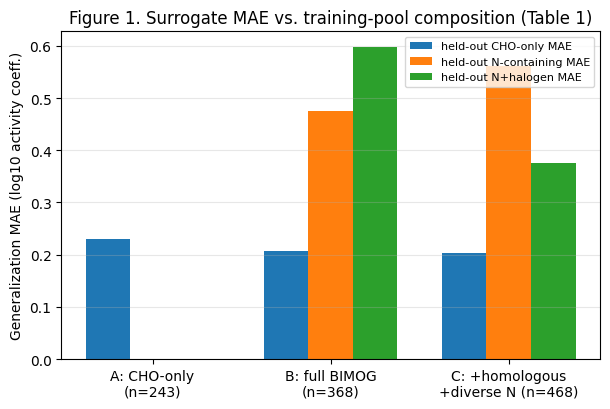

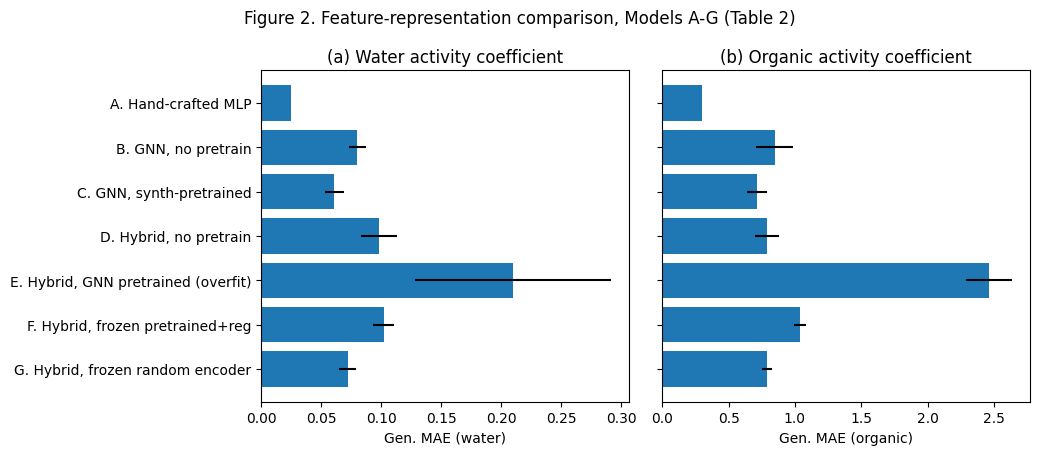

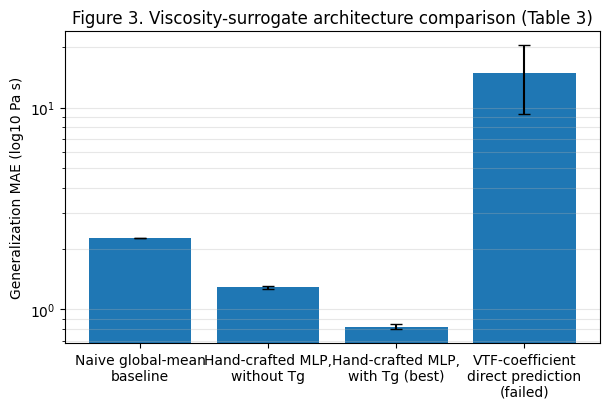

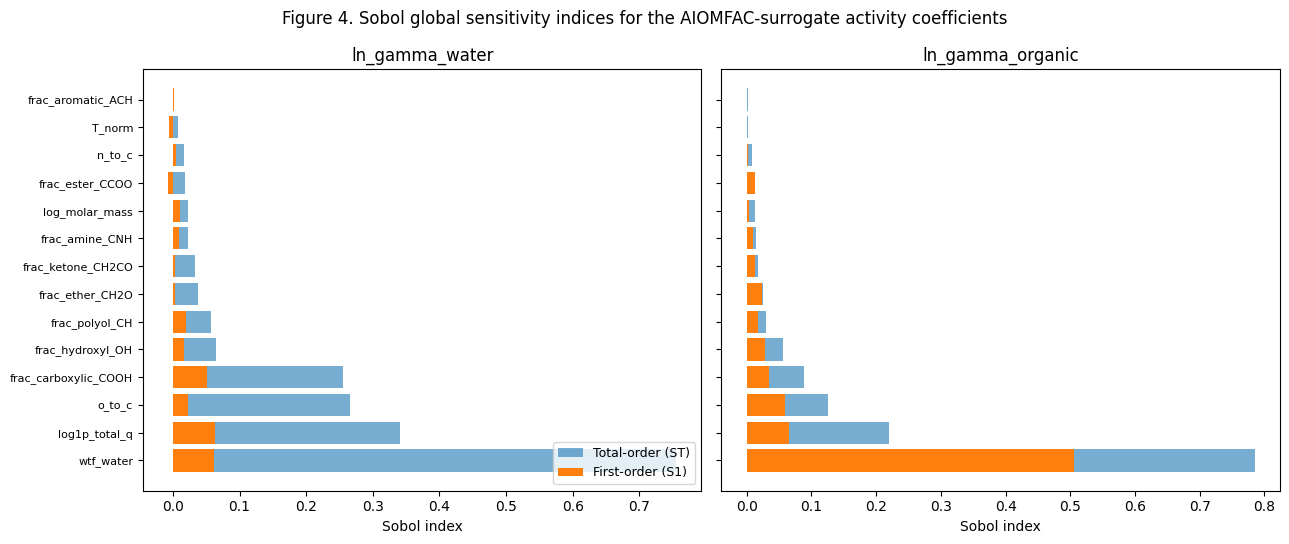

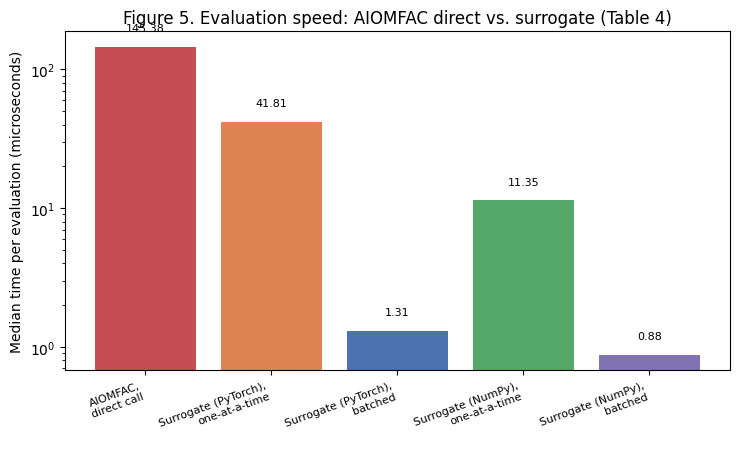

In [37]:
# ---------------------------------------------------------------------------
# Reproduce Figures 1-4 of the paper from this notebook's own results tables.
# Fill in TABLE1 / TABLE2 / TABLE3 from the printed outputs of Parts I-III above
# (they are reproduced here with the values reported in the paper so the figures
# render even before re-running the full pipeline; replace with your own numbers
# if you retrain and get different results).
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---- Figure 1 (Table 1): MAE by training pool and held-out category ----
pools = ['A: CHO-only\n(n=243)', 'B: full BIMOG\n(n=368)', 'C: +homologous\n+diverse N (n=468)']
mae_n_only = [np.nan, 0.476, 0.561]
mae_n_hal  = [np.nan, 0.598, 0.375]
mae_cho    = [0.230, 0.208, 0.204]
x = np.arange(len(pools)); w = 0.25
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.bar(x - w, mae_cho, width=w, label='held-out CHO-only MAE')
ax.bar(x,     mae_n_only, width=w, label='held-out N-containing MAE')
ax.bar(x + w, mae_n_hal, width=w, label='held-out N+halogen MAE')
ax.set_xticks(x); ax.set_xticklabels(pools)
ax.set_ylabel('Generalization MAE (log10 activity coeff.)')
ax.set_title('Figure 1. Surrogate MAE vs. training-pool composition (Table 1)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); plt.show()

# ---- Figure 2 (Table 2): Model A-G comparison ----
models = ['A. Hand-crafted MLP', 'B. GNN, no pretrain', 'C. GNN, synth-pretrained',
          'D. Hybrid, no pretrain', 'E. Hybrid, GNN pretrained (overfit)',
          'F. Hybrid, frozen pretrained+reg', 'G. Hybrid, frozen random encoder']
mae_water   = [0.025, 0.080, 0.061, 0.098, 0.210, 0.102, 0.072]
mae_water_e = [0.0,   0.007, 0.008, 0.015, 0.082, 0.009, 0.007]
mae_organic   = [0.298, 0.847, 0.715, 0.791, 2.465, 1.039, 0.791]
mae_organic_e = [0.0,   0.138, 0.075, 0.090, 0.175, 0.044, 0.036]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
axes[0].barh(models, mae_water, xerr=mae_water_e); axes[0].invert_yaxis()
axes[0].set_xlabel('Gen. MAE (water)'); axes[0].set_title('(a) Water activity coefficient')
axes[1].barh(models, mae_organic, xerr=mae_organic_e); axes[1].invert_yaxis()
axes[1].set_yticklabels([]); axes[1].set_xlabel('Gen. MAE (organic)')
axes[1].set_title('(b) Organic activity coefficient')
fig.suptitle('Figure 2. Feature-representation comparison, Models A-G (Table 2)')
fig.tight_layout(); plt.show()

# ---- Figure 3 (Table 3): viscosity-pipeline MAE ----
vmodels = ['Naive global-mean\nbaseline', 'Hand-crafted MLP,\nwithout Tg',
           'Hand-crafted MLP,\nwith Tg (best)', 'VTF-coefficient\ndirect prediction\n(failed)']
vmae = [2.267, 1.286, 0.823, 14.8]; vmae_e = [0.0, 0.019, 0.020, 5.5]
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.bar(vmodels, vmae, yerr=vmae_e, capsize=4); ax.set_yscale('log')
ax.set_ylabel('Generalization MAE (log10 Pa s)')
ax.set_title('Figure 3. Viscosity-surrogate architecture comparison (Table 3)')
ax.grid(axis='y', which='both', alpha=0.3)
fig.tight_layout(); plt.show()

# ---- Figure 4: Sobol indices ----
# Part IV (the Direction 5 GSA cells above) defines `names`, `Si_water`, and `Si_organic`
# directly (it does not write a JSON file or a `sobol_results` dict) -- use those if this
# notebook was run top to bottom; otherwise fall back to a bundled results file if you
# have one (e.g. the `sobol_results.json` delivered alongside the earlier, full-N=2048
# research run), which must be uploaded/placed in the working directory first.
try:
    _targets = {'ln_gamma_water': Si_water, 'ln_gamma_organic': Si_organic}  # noqa: F821
    _names = names  # noqa: F821
except NameError:
    import json as _json
    with open('sobol_results.json') as _f:  # upload this file to the Colab session first
        _sob = _json.load(_f)
    _names = _sob['factor_names']
    _targets = {k: {'S1': _sob[k]['S1'], 'ST': _sob[k]['ST']}
                for k in _sob if k.startswith('ln_gamma')}

fig, axes = plt.subplots(1, len(_targets), figsize=(6.5*len(_targets), 5.5), sharey=True)
if len(_targets) == 1:
    axes = [axes]
for ax, (tgt, Si) in zip(axes, _targets.items()):
    S1 = np.asarray(Si['S1']); ST = np.asarray(Si['ST'])
    order = np.argsort(ST)[::-1]; y = np.arange(len(_names))
    ax.barh(y, ST[order], alpha=0.6, label='Total-order (ST)')
    ax.barh(y, S1[order], label='First-order (S1)')
    ax.set_yticks(y); ax.set_yticklabels([_names[i] for i in order], fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel('Sobol index'); ax.set_title(tgt)
axes[0].legend(fontsize=9, loc='lower right')
fig.suptitle('Figure 4. Sobol global sensitivity indices for the AIOMFAC-surrogate activity coefficients')
fig.tight_layout(); plt.show()

# ---- Figure 5 (Table 4): speed benchmark -- uses this run's own timings from Part V ----
try:
    _per_eval_us = [np.median(aiomfac_times)*1e6, np.median(single_times)*1e6, batched_per_point*1e6,
                    np.median(np_single_times)*1e6, np_batched_per_point*1e6]
except NameError:
    _per_eval_us = [140.26, 40.20, 1.88, 11.10, 0.91]  # paper-reported fallback if Part V was skipped
fig, ax = plt.subplots(figsize=(7.5, 4.6))
_labels = ['AIOMFAC,\ndirect call', 'Surrogate (PyTorch),\none-at-a-time', 'Surrogate (PyTorch),\nbatched',
           'Surrogate (NumPy),\none-at-a-time', 'Surrogate (NumPy),\nbatched']
bars = ax.bar(range(5), _per_eval_us, color=['#C44E52', '#DD8452', '#4C72B0', '#55A868', '#8172B2'])
ax.set_xticks(range(5)); ax.set_xticklabels(_labels, fontsize=8, rotation=20, ha='right')
ax.set_yscale('log'); ax.set_ylabel('Median time per evaluation (microseconds)')
ax.set_title('Figure 5. Evaluation speed: AIOMFAC direct vs. surrogate (Table 4)')
for b, v in zip(bars, _per_eval_us):
    ax.text(b.get_x()+b.get_width()/2, v*1.3, f'{v:.2f}', ha='center', fontsize=8)
fig.tight_layout(); plt.show()


---
## Save every trained model from this run

The four source notebooks above keep their trained models only in memory -- none of Parts I-IV checkpoint anything to disk on their own as written. (The `surrogate_weights.pt` file delivered alongside this notebook came from a separate, standalone training script run outside this notebook, not from Part IV's cells above.) The cell below scans the current namespace for every `torch.nn.Module` instance left over from Parts I-IV and saves each one's `state_dict()` to `./saved_models/`, so a full run of this notebook leaves you with a checkpoint for every comparison row in Tables 1-3, not just the one that happened to be saved previously.

In [38]:
import os
import torch
import torch.nn as nn

os.makedirs('saved_models', exist_ok=True)
saved = []
for _name, _obj in list(globals().items()):
    if isinstance(_obj, nn.Module) and not _name.startswith('_'):
        _path = f'saved_models/{_name}.pt'
        torch.save(_obj.state_dict(), _path)
        saved.append(_path)
print(f'saved {len(saved)} model(s):')
for _p in saved:
    print(' ', _p)
print('\n(zip and download saved_models/ to keep every trained model from this run, e.g.:)')
print('  import shutil; shutil.make_archive("saved_models", "zip", "saved_models")')


saved 7 model(s):
  saved_models/model_full.pt
  saved_models/modelA.pt
  saved_models/loss_fn.pt
  saved_models/modelB.pt
  saved_models/modelC.pt
  saved_models/modelD.pt
  saved_models/model.pt

(zip and download saved_models/ to keep every trained model from this run, e.g.:)
  import shutil; shutil.make_archive("saved_models", "zip", "saved_models")


---
## Summary

Running all five parts in order reproduces Tables 1-4 and Figures 1-5 of `aiomfac_surrogate_paper_draft.docx` end to end from a single notebook. The trained surrogate weights used for the Part IV Sobol analysis (`surrogate_weights.pt` / `surrogate_norm.npz` / `surrogate_meta.json`) are also delivered as standalone files alongside this notebook, so the GSA (or any other downstream use of the surrogate) can be rerun without repeating Part I's training step.